In [152]:
import numpy as np
from dataclasses import dataclass
from typing import Optional
try:
    from scipy.integrate import quad
    _HAS_SCIPY = True
except Exception:
    _HAS_SCIPY = False
from astropy import units as u
from astropy import constants as const

C_KMS = const.c.to(u.km/u.s).value

@dataclass
class CosmoParams:
    H0: float = 70.0            # [km/s/Mpc]
    Om0: float = 0.3            # Ω_m
    Ok0: float = 0.0            # Ω_k
    Or0: float = 0.0            # Ω_r (可忽略时设 0)
    # 暗能量状态方程：二选一
    w: Optional[float] = None      # 常数 w
    w0: float = -1.0            # CPL: w(a)=w0+wa(1-a)
    wa: float = 0.0

    def Ode0(self) -> float:
        return 1.0 - self.Om0 - self.Ok0 - self.Or0

def _rho_de_factor(z: float, cp: CosmoParams) -> float:
    """ρ_DE(z)/ρ_DE(0) 的无量纲演化因子。"""
    if cp.w is not None:  # 常数 w
        return (1.0 + z)**(3.0 * (1.0 + cp.w))
    # CPL: w(a)=w0+wa(1-a) => ρ_DE ∝ (1+z)^{3(1+w0+wa)} exp[-3 wa z/(1+z)]
    return (1.0 + z)**(3.0 * (1.0 + cp.w0 + cp.wa)) * np.exp(-3.0 * cp.wa * z / (1.0 + z))

def Ez(z: float, cp: CosmoParams) -> float:
    """E(z) = H(z)/H0."""
    de = cp.Ode0() * _rho_de_factor(z, cp)
    return np.sqrt(cp.Om0 * (1.0 + z)**3 + cp.Or0 * (1.0 + z)**4 + cp.Ok0 * (1.0 + z)**2 + de)

def _chi_quad(z: float, cp: CosmoParams) -> float:
    """无量纲共动径向距离 χ(z) = ∫_0^z dz'/E(z')."""
    if _HAS_SCIPY:
        val, _ = quad(lambda zp: 1.0 / Ez(zp, cp), 0.0, float(z), epsrel=1e-8, epsabs=0.0, limit=256)
        return val
    # 简单梯形积分后备方案
    zgrid = np.linspace(0.0, float(z), 4097)
    return np.trapz(1.0 / np.vectorize(Ez)(zgrid, cp), zgrid)

def _Sk(x: float, Ok0: float) -> float:
    """曲率函数 S_k(x)。注意这里的 x 是 √|Ω_k| χ。"""
    if abs(Ok0) < 1e-12:
        return x
    if Ok0 > 0.0:  # open, sinh
        return np.sinh(x)
    else:          # closed, sin
        return np.sin(x)

def D_M(z: float, cp: CosmoParams) -> float:
    """横向共动距离 D_M(z) [Mpc]."""
    chi = _chi_quad(z, cp)
    if abs(cp.Ok0) < 1e-12:
        return (C_KMS / cp.H0) * chi
    sqrtOk = np.sqrt(abs(cp.Ok0))
    return (C_KMS / cp.H0) * _Sk(sqrtOk * chi, cp.Ok0) / sqrtOk

def D_A(z: float, cp: CosmoParams) -> float:
    """角径距 D_A(0→z) [Mpc]."""
    return D_M(z, cp) / (1.0 + z)

def D_A12(z1: float, z2: float, cp: CosmoParams) -> float:
    """两红移间角径距 D_A(z1→z2) [Mpc], 需 z2>z1。"""
    if not (z2 > z1):
        raise ValueError("Require z2 > z1 for D_A12.")
    chi1 = _chi_quad(z1, cp)
    chi2 = _chi_quad(z2, cp)
    dchi = chi2 - chi1
    if abs(cp.Ok0) < 1e-12:
        DM12 = (C_KMS / cp.H0) * dchi
    else:
        sqrtOk = np.sqrt(abs(cp.Ok0))
        DM12 = (C_KMS / cp.H0) * _Sk(sqrtOk * dchi, cp.Ok0) / sqrtOk
    return DM12 / (1.0 + z2)

# ---- 封装常用距离 ----
def Dl(zl: float, cp: CosmoParams) -> float: return D_A(zl, cp)
def Ds(zs: float, cp: CosmoParams) -> float: return D_A(zs, cp)
def Dls(zl: float, zs: float, cp: CosmoParams) -> float: return D_A12(zl, zs, cp)

# =========================
# 1) 星系–星系透镜：R = Ds / Dls
# =========================
def galaxy_lens_distance_ratio(zl: float, zs: float, *,
                               H0: float, omega_m: float,
                               omega_k: float = 0.0, omega_r: float = 0.0,
                               w: Optional[float] = None, w0: float = -1.0, wa: float = 0.0) -> float:
    """
    返回 R = D_s / D_ls （无量纲），仅含宇宙学部分。
    注：真实建模还需乘以结构因子 F(γ, β_ani, θ_ap/θ_E) 才能与(θ_E, σ_ap)组合。
    """
    cp = CosmoParams(H0=H0, Om0=omega_m, Ok0=omega_k, Or0=omega_r, w=w, w0=w0, wa=wa)
    return Ds(zs, cp) / Dls(zl, zs, cp)

# =========================
# 2) 时延 AGN：D_dt = (1+zl) Dl Ds / Dls
# =========================
def time_delay_distance(zl: float, zs: float, *,
                        H0: float, omega_m: float,
                        omega_k: float = 0.0, omega_r: float = 0.0,
                        w: Optional[float] = None, w0: float = -1.0, wa: float = 0.0) -> float:
    """
    返回时延距离 D_Δt [Mpc]： (1+zl) * Dl * Ds / Dls
    注意：观测上 D_Δt 还会被外会聚 κ_ext 等效缩放，建模需单独处理。
    """
    cp = CosmoParams(H0=H0, Om0=omega_m, Ok0=omega_k, Or0=omega_r, w=w, w0=w0, wa=wa)
    return (1.0 + zl) * Dl(zl, cp) * Ds(zs, cp) / Dls(zl, zs, cp)

# =========================
# 3) 双源透镜：β_DSP = (D_ls2/D_s2) / (D_ls1/D_s1)
# =========================
def double_source_beta(zl: float, zs1: float, zs2: float, *,
                       H0: float, omega_m: float,
                       omega_k: float = 0.0, omega_r: float = 0.0,
                       w: Optional[float] = None, w0: float = -1.0, wa: float = 0.0) -> float:
    """
    返回双源透镜的宇宙学量 β_DSP （无量纲）。
    要求 zl < zs1 < zs2。
    """
    if not (zl < zs1 < zs2):
        raise ValueError("Require zl < zs1 < zs2 for double-source lensing.")
    cp = CosmoParams(H0=H0, Om0=omega_m, Ok0=omega_k, Or0=omega_r, w=w, w0=w0, wa=wa)
    num = Dls(zl, zs2, cp) / Ds(zs2, cp)
    den = Dls(zl, zs1, cp) / Ds(zs1, cp)
    return num / den

import numpy as np

def _as_float(x):
    # 确保传给积分器的是标量 float
    return float(np.asarray(x))

def galaxy_lens_distance_ratio_vec(
    zl, zs, *, H0, omega_m, omega_k=0.0, omega_r=0.0,
    w=None, w0=-1.0, wa=0.0
):
    """
    向量化版本：返回 R = Ds/Dls（与 zl、zs 广播后的形状一致）。
    不满足 zs>zl 的元素返回 np.nan。
    """
    cp = CosmoParams(H0=H0, Om0=omega_m, Ok0=omega_k, Or0=omega_r, w=w, w0=w0, wa=wa)
    zlA, zsA = np.broadcast_arrays(np.asarray(zl, float), np.asarray(zs, float))
    out = np.empty_like(zlA, dtype=float)
    it = np.nditer([zlA, zsA, out], flags=['multi_index'],
                   op_flags=[['readonly'], ['readonly'], ['writeonly']])
    for zl_i, zs_i, o in it:
        zl_f, zs_f = _as_float(zl_i), _as_float(zs_i)
        if zs_f <= zl_f:
            o[...] = np.nan
        else:
            # o[...] = Ds(zs_f, cp) / Dls(zl_f, zs_f, cp)
            o[...] = Dls(zl_f, zs_f, cp) / Ds(zs_f, cp)
    return out

def time_delay_distance_vec(
    zl, zs, *, H0, omega_m, omega_k=0.0, omega_r=0.0,
    w=None, w0=-1.0, wa=0.0
):
    """
    向量化版本：返回 D_dt [Mpc] = (1+zl) * Dl * Ds / Dls。
    不满足 zs>zl 的元素返回 np.nan。
    """
    cp = CosmoParams(H0=H0, Om0=omega_m, Ok0=omega_k, Or0=omega_r, w=w, w0=w0, wa=wa)
    zlA, zsA = np.broadcast_arrays(np.asarray(zl, float), np.asarray(zs, float))
    out = np.empty_like(zlA, dtype=float)
    it = np.nditer([zlA, zsA, out], flags=['multi_index'],
                   op_flags=[['readonly'], ['readonly'], ['writeonly']])
    for zl_i, zs_i, o in it:
        zl_f, zs_f = _as_float(zl_i), _as_float(zs_i)
        if zs_f <= zl_f:
            o[...] = np.nan
        else:
            o[...] = (1.0 + zl_f) * Dl(zl_f, cp) * Ds(zs_f, cp) / Dls(zl_f, zs_f, cp)
    return out

def double_source_beta_vec(
    zl, zs1, zs2, *, H0, omega_m, omega_k=0.0, omega_r=0.0,
    w=None, w0=-1.0, wa=0.0
):
    """
    向量化版本：返回 β_DSP = (D_ls2/D_s2)/(D_ls1/D_s1)。
    仅当 zl < zs1 < zs2 时有效，否则该元素 np.nan。
    """
    cp = CosmoParams(H0=H0, Om0=omega_m, Ok0=omega_k, Or0=omega_r, w=w, w0=w0, wa=wa)
    zlA, z1A, z2A = np.broadcast_arrays(np.asarray(zl, float),
                                        np.asarray(zs1, float),
                                        np.asarray(zs2, float))
    out = np.empty_like(zlA, dtype=float)
    it = np.nditer([zlA, z1A, z2A, out], flags=['multi_index'],
                   op_flags=[['readonly'], ['readonly'], ['readonly'], ['writeonly']])
    for zl_i, z1_i, z2_i, o in it:
        zl_f, z1_f, z2_f = _as_float(zl_i), _as_float(z1_i), _as_float(z2_i)
        if not (zl_f < z1_f < z2_f):
            o[...] = np.nan
        else:
            num = Dls(zl_f, z2_f, cp) / Ds(z2_f, cp)
            den = Dls(zl_f, z1_f, cp) / Ds(z1_f, cp)
            o[...] = num / den
    return out



In [46]:
import os
import numpy as np
import pandas as pd
import scipy.integrate as sci
import matplotlib.pyplot as plt

from astropy.table import Table
from astropy import units as u
from astropy import constants as const
from scipy.special import gamma as fgamma

# ───────────────────────────────────────────────────────────────
# 0) Load data
# ───────────────────────────────────────────────────────────────
tab = Table.read(r"/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/SGLTable03.fits")

# Make plain numpy arrays (drop units if present)
zl        = np.asarray(tab['zl'], dtype=float)
zs        = np.asarray(tab['zs'], dtype=float)
theta_ap_arcsec = np.asarray(tab['theta_ap'], dtype=float)
sigma_ap  = np.asarray(tab['sigma_ap'], dtype=float)

# Aperture‐correction parameters (defined but not used below)
eta, eta_err = -0.066, 0.035
def calibrate(sigma_ap_nocal, theta_eff, theta_ap, eta):
    return sigma_ap_nocal * (theta_eff / (2*theta_ap))**eta
def sigma_uncertainty(sigma_ap_nocal, sigma_ap_err_nocal, theta_eff, theta_ap, eta, eta_err):
    fac = (theta_eff / (2*theta_ap))
    err_stat2 = sigma_ap_err_nocal**2
    err_AC2   = (sigma_ap_err_nocal**2) * fac**(2*eta) \
              + (sigma_ap_nocal**2) * fac**(2*eta) * (np.log(fac)**2) * (eta_err**2)
    err_sys2  = (0.03 * sigma_ap_nocal)**2
    return np.sqrt(err_stat2 + err_AC2 + err_sys2)

# ───────────────────────────────────────────────────────────────
# σ–θ_E relation for a spherical power-law (γ)
# ───────────────────────────────────────────────────────────────
pi = np.pi

def f_gamma(g):
    a = -1.0/np.sqrt(pi)
    b = ((5.0 - 2.0*g)*(1.0 - g)) / (3.0 - g)
    c = fgamma(g - 1.0) / fgamma(g - 1.5)
    d = fgamma((g - 1.0)/2.0) / fgamma(g/2.0)
    return a * b * c * d**2

def f_prime(g, d, beta):
    pref = 1.0 / (2.0 * np.sqrt(np.pi))
    term1 = (g + d - 5.0) * (g + d - 2.0 - 2.0*beta) / (d - 3.0)
    num = fgamma((g + d - 2.0)/2.0) * fgamma((g + d)/2.0)
    den = fgamma((g + d)/2.0) * fgamma((g + d - 3.0)/2.0) \
        - beta * fgamma((g + d - 2.0)/2.0) * fgamma((g + d - 1.0)/2.0)
    term3 = fgamma((d - 1.0)/2.0) * fgamma((g - 1.0)/2.0) / (fgamma(d/2.0) * fgamma(g/2.0))
    return pref * term1 * (num/den) * term3

def thetaE_theo(gamma, Dls, Ds, theta_ap_rad, sigma_ap_kms):
    """
    Returns θ_E in radians for (possibly array) gamma.
    Uses the standard power-law relation; reduces to SIS when gamma=2.
    """
    p1 = 4.0*pi*(sigma_ap_kms**2)/(c_kms**2) * (Dls/Ds) * (theta_ap_rad**(gamma - 2.0)) * f_gamma(gamma)
    return p1**(1.0/(gamma - 1.0))

def thetaE_theo_EPL(g,d,b, Dls, Ds, theta_ap_rad, sigma_ap_kms):
    """
    Returns θ_E in radians for (possibly array) gamma.
    Uses the standard power-law relation; reduces to SIS when gamma=2.
    """
    p1 = 4.0*pi*(sigma_ap_kms**2)/(c_kms**2) * (Dls/Ds) * (theta_ap_rad**(g - 2.0)) * f_prime(g,d,b)
    return p1**(1.0/(g - 1.0))


In [47]:

if __name__ == "__main__":
    cosmo = dict(H0=70.0, omega_m=0.3, omega_k=0.0, w=-1.0)

    R = galaxy_lens_distance_ratio_vec(zl, zs, **cosmo)
    Ddt = time_delay_distance_vec(zl, zs, **cosmo)

    # print("R = Ds/Dls =", R)
    # print("D_dt [Mpc] =", Ddt)

In [62]:
import numpy as np
import emcee
from multiprocessing import Pool
import os
from astropy.constants import G, c, M_sun

import math

# Load values - GLOBAL VALUES
c_km = c.to('km/s').value
pi = np.pi

def E2_wCDM(z, Om, ok, w, Or=0.0):

    Ode = 1.0 - Om - ok - Or
    if Ode <= 0.0:
        return np.nan

    return Om*(1.0+z)**3 + Or*(1.0+z)**4 + ok*(1.0+z)**2 + Ode*(1.0+z)**(3.0*(1.0+w))

def E2_positive_on_grid(Om, ok, w, z1, z2, n=8):
    if z2 <= z1:
        return True  
    zz = np.linspace(z1, z2, n)
    Ez2 = E2_wCDM(zz, Om, ok, w)
    return np.all(np.isfinite(Ez2)) and np.all(Ez2 > 0.0)

def Sk_of_chi(chi, ok):
    # comoving transverse distance projector with curvature
    if abs(ok) < 1e-10:
        return chi
    s = np.sqrt(abs(ok))
    y = s * chi

    if abs(y) < 1e-6:

        return chi + (np.sign(ok) * ok) * chi**3 / 6.0
    return np.sinh(y)/s if ok > 0 else np.sin(y)/s


def integrate_da_good_kw(z1, z2, w, ok, H0, Om, c_km):
    if not (np.isfinite(z1) and np.isfinite(z2)):
        return np.nan
    if z2 <= z1:
        return 0.0

    if not E2_positive_on_grid(Om, ok, w, z1, z2, n=8):
        return np.nan

    def inv_E(z):
        Ez2 = E2_wCDM(z, Om, ok, w)

        if not np.isfinite(Ez2) or Ez2 <= 0.0:
            return np.inf
        return 1.0 / np.sqrt(Ez2)

    chi, err = sci.quad(inv_E, z1, z2, epsabs=1e-8, epsrel=1e-8, limit=200)
    if not np.isfinite(chi):
        return np.nan


    Dc = (c_km / H0) * chi
    Dm = Sk_of_chi(Dc * H0 / c_km, ok) * (c_km / H0) 
    DA = Dm / (1.0 + z2)
    return DA

# -------------------------------------------------
# 0) 理论量：dd_th = D_ls / D_s  （保持你的实现不变）
# -------------------------------------------------
def dd_th(Om, w, zl, zs, H0):
    D_s  = integrate_da_good_kw(0.,  zs, w, 0., H0, Om, c_km)
    D_ls = integrate_da_good_kw(zl, zs, w, 0., H0, Om, c_km)
    return D_ls / D_s

# =================================================
# 1) 直接观测量与 log-likelihood
# =================================================
def lnlike_dd_direct(Om, w, zl_arr, zs_arr, dd_obs_arr, dd_obs_err_arr, H0,
                     sigma_is_fractional=False, sigma_floor=1e-6):
    """
    观测给定为直接的 dd_obs (= D_ls/D_s)，误差是绝对误差或分数误差。
    在 log 空间做高斯似然： ln dd_th vs ln dd_obs
    """
    zl_arr = np.asarray(zl_arr, float)
    zs_arr = np.asarray(zs_arr, float)
    dd_obs_arr = np.asarray(dd_obs_arr, float)
    dd_obs_err_arr = np.asarray(dd_obs_err_arr, float)

    # 基本掩码：物理 & 有限
    m = (zs_arr > zl_arr) & np.isfinite(dd_obs_arr) & np.isfinite(dd_obs_err_arr) \
        & (dd_obs_arr > 0) & (dd_obs_err_arr > 0)
    if not np.any(m):
        return -np.inf

    zl = zl_arr[m]; zs = zs_arr[m]
    dd_obs = dd_obs_arr[m]; dd_err = dd_obs_err_arr[m]

    # 理论值（逐个算，兼容你现有的 dd_th 标量函数）
    dd_th_arr = np.array([dd_th(Om, w, zli, zsi, H0) for zli, zsi in zip(zl, zs)])
    if np.any(~np.isfinite(dd_th_arr)) or np.any(dd_th_arr <= 0):
        return -np.inf

    # log 空间误差
    if sigma_is_fractional:
        sigma_ln = np.clip(dd_err, sigma_floor, None)     # dd_err 已是分数误差
    else:
        sigma_ln = np.clip(dd_err / dd_obs, sigma_floor, None)

    delta = np.log(dd_th_arr) - np.log(dd_obs)
    var   = sigma_ln**2

    # 带常数项的高斯对数似然（不带常数也可以，结果只差一个常数）
    lnL = -0.5 * np.sum(delta**2 / var + np.log(2*np.pi*var))
    return float(lnL)

# 统一的先验
def lnprior_2D(theta):
    Om, w = theta
    if 0.02 < Om < 1.0 and -4.0 < w < 2.0:
        return 0.0
    return -np.inf

def lnprob_cos2D_direct(theta, zl, zs, dd_obs, dd_obs_err, H0,
                        sigma_is_fractional=False):
    lp = lnprior_2D(theta)
    if not np.isfinite(lp):
        return -np.inf
    Om, w = theta
    ll = lnlike_dd_direct(Om, w, zl, zs, dd_obs, dd_obs_err, H0,
                          sigma_is_fractional=sigma_is_fractional)
    return lp + ll

# =================================================
# 2) 运行 emcee（多进程 + 每 2000 步 checkpoint）
# =================================================
import numpy as np
import emcee
import os, glob
from multiprocessing import Pool

def run_mcmc_dd(zl, zs, dd_obs, dd_obs_err, H0,
                init=(0.3, -1.0), nwalkers=32, nsteps=10000,
                threads=8, out_prefix="mcmc_dd_direct",
                sigma_is_fractional=False, random_seed=42,
                checkpoint_size = 1000,
                burnin_to_save=1000, thin_to_save=1):
    """
    以 dd_obs 直接约束 (Om, w)。
    - 每 2000 步写 checkpoint: {out_prefix}_chk{chunk:03d}.npz
    - 结束时仅保存丢弃 burn-in、thin 后且保持三维结构的链：
        {out_prefix}_chain_kept.npy  (shape = (nsteps_kept, nwalkers, ndim))
    - 随后删除所有 checkpoint 文件。
    """
    rng = np.random.default_rng(random_seed)
    ndim = 2
    Om0, w0 = init

    p0 = np.array([Om0, w0])
    spread = np.array([0.02, 0.05])
    p0_walkers = p0 + spread * rng.normal(size=(nwalkers, ndim))

    # 保证初始化落在先验范围
    for k in range(nwalkers):
        tries = 0
        while not np.isfinite(lnprior_2D(p0_walkers[k])) and tries < 1000:
            p0_walkers[k] = p0 + spread * rng.normal(size=ndim)
            tries += 1
        if not np.isfinite(lnprior_2D(p0_walkers[k])):
            raise RuntimeError("Could not initialize walkers inside prior bounds.")

    log_prob_args = (zl, zs, dd_obs, dd_obs_err, H0, sigma_is_fractional)

    with Pool(processes=threads) as pool:
        sampler = emcee.EnsembleSampler(
            nwalkers, ndim, lnprob_cos2D_direct, args=log_prob_args, pool=pool
        )

        state = p0_walkers
        chunk = checkpoint_size
        n_chunks = int(np.ceil(nsteps / chunk))
        for i in range(n_chunks):
            n_this = chunk if (i < n_chunks - 1) else (nsteps - chunk * (n_chunks - 1))
            state = sampler.run_mcmc(state, n_this, progress=True)

            # --- checkpoint ---
            chk_path = f"{out_prefix}_chk{i+1:03d}.npz"
            np.savez(
                chk_path,
                chain=sampler.get_chain(),
                log_prob=sampler.get_log_prob(),
                acceptance_fraction=sampler.acceptance_fraction,
                last_state_pos=state.coords,
                last_state_log_prob=state.log_prob
            )
            print(f"[Checkpoint] saved to {chk_path}")

        # -------- 保存丢弃 burn-in + 抽样后的三维链 --------
        # emcee 的 get_chain 支持 discard/thin 并保持 (nsteps_kept, nwalkers, ndim) 形状
        chain_kept = sampler.get_chain(discard=burnin_to_save, thin=thin_to_save, flat=False)
        kept_path = f"{out_prefix}_chain_kept.npy"
        np.save(kept_path, chain_kept)
        print(f"[Saved] kept chain -> {kept_path}  shape={chain_kept.shape}")

        # -------- 删除所有 checkpoint 文件 --------
        for fp in glob.glob(f"{out_prefix}_chk*.npz"):
            try:
                os.remove(fp)
                print(f"[Cleanup] removed {fp}")
            except Exception as e:
                print(f"[Cleanup] failed to remove {fp}: {e}")

        return sampler, state





In [64]:
# # =========================
# # 3) 使用示例
# # =========================
# # 假设你已有等长数组：
# # zl, zs: 透镜/源红移
# # dd_obs_arr: 直接观测的 D_ls/D_s
# # dd_obs_err_arr: 其 1σ 误差（绝对；若为分数误差，传 sigma_is_fractional=True）
# # H0 固定为数据使用的值（例如 70.0）
# # 
# out_path = r"/home/astrodust/SG/sgl_cosmo/codes/Output"
# out_name = r"0.01_bias"


# sampler, state = run_mcmc_dd(
#     zl, zs, R*1.01, R*0.01, H0=70.0,
#     init=(0.3, -1.0), nwalkers=200, nsteps=8000,
#     threads=12, out_prefix=f"{out_path}/{out_name}",
#     sigma_is_fractional=False,
#     checkpoint_size = 1000
# )
# chain = sampler.get_chain(discard=2000, thin=10, flat=True)

In [65]:
import os
import numpy as np
import matplotlib.pyplot as plt
from getdist import plots, MCSamples

def get_base_dir():
    # In a script, __file__ exists; in notebooks it doesn't
    if '__file__' in globals():
        return os.path.dirname(os.path.abspath(__file__))
    else:
        return os.getcwd()

def calculate_marginal_median_and_mad(samples):
    nwalkers, nsteps, ndim = samples.shape
    flat = samples.reshape(-1, ndim)
    med = np.median(flat, axis=0)
    mad = np.median(np.abs(flat - med), axis=0)
    return med, mad

def calculate_marginal_peak_and_mad(samples, bins='auto'):
    nwalkers, nsteps, ndim = samples.shape
    flat = samples.reshape(-1, ndim)

    peaks = np.empty(ndim)
    mads  = np.empty(ndim)

    for i in range(ndim):
        data = flat[:, i]

        # 1) Histogram-based mode estimate
        hist, edges = np.histogram(data, bins=bins, density=True)
        # find the bin with maximum density
        idx_peak = np.argmax(hist)
        # mode ≈ midpoint of that bin
        peaks[i] = 0.5*(edges[idx_peak] + edges[idx_peak+1])

        # 2) MAD around the mode
        mads[i] = np.median(np.abs(data - peaks[i]))

    return peaks, mads

def plot_triangle_one(samples, param_names, label,
                      output_folder, plot_name, marker=True):
    mcs = MCSamples(samples=samples, names=param_names, label=label)
    g = plots.getSubplotPlotter(width_inch=8)
    g.settings.title_limit_fontsize = 14
    g.settings.axes_fontsize = 14
    g.settings.axes_labelsize = 14

    g.triangle_plot(
        [mcs], param_names,
        filled=True,
        contour_colors=['#4169E1'],
        contour_lws=[1.5],
        alpha=0.6
    )

    if marker:
        medians, mads = calculate_marginal_peak_and_mad(samples)
        for i, x0 in enumerate(medians):
            ax = g.subplots[i, i]
            ax.axvline(x0, color='k', ls='--')
            ax.set_title(f"{param_names[i]} = {medians[i]:.3f}±{mads[i]:.3f}",
                         fontsize=12)

    os.makedirs(output_folder, exist_ok=True)
    plt.savefig(os.path.join(output_folder, plot_name),
                bbox_inches='tight', dpi=200)
    plt.show()
    

Removed no burn in


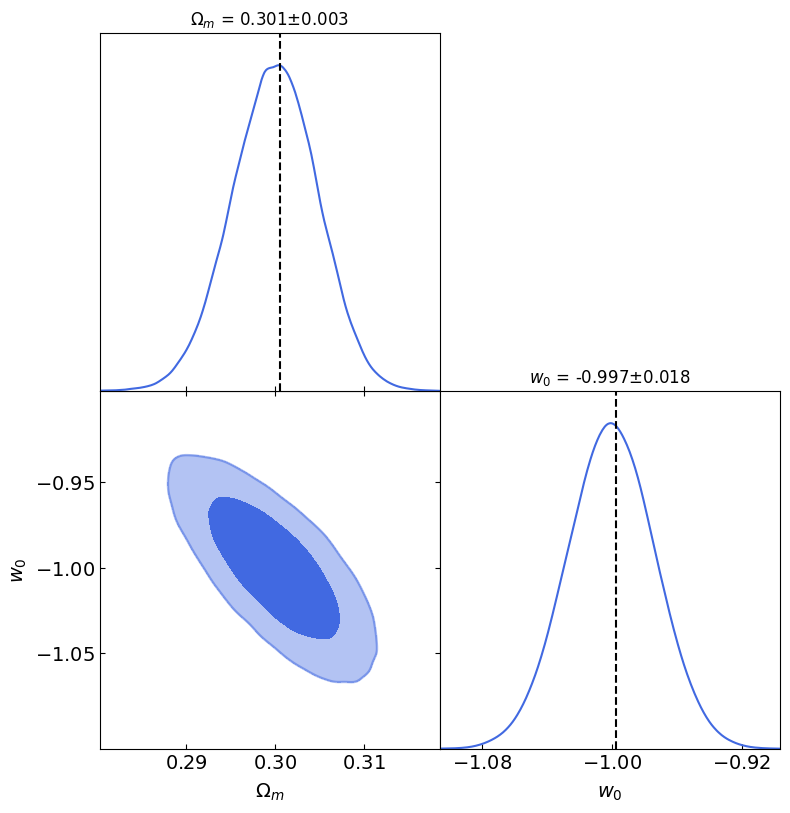

In [56]:


# # ———————————————— usage ——————————————————
# base_dir = r'/home/astrodust/SG/sgl_cosmo/codes'
# evo_label = r"0_bias"
# prior_label = r"check01"

# # 1) Four parameter names in LaTeX
# param_names = [r'$\Omega_m$', r'$w_0$']

# # 2) Load the single chain from relative path
# samples_file = os.path.join(base_dir, 'Output', f"_chain.npy")
# samples = np.load(samples_file)  # shape (nwalkers, nsteps, ndim)

# # 3) Call the plot routine with relative output folder
# plot_triangle_one(
#     samples=samples,
#     param_names=param_names,
#     label=f'{evo_label}_{prior_label}',
#     output_folder=os.path.join(base_dir, 'Results'),
#     plot_name=f'triangle_2D_{evo_label}-{prior_label}.png',
#     marker=True
# )


In [74]:
def _normalize_pairs(evo_labels, prior_labels):
    """
    Accept either:
      - evo_labels: list[str], prior_labels: list[str] of same length
      - evo_labels: list[tuple[str,str]] and prior_labels: None/[]
    Returns: list of (evo, prior)
    """
    if prior_labels is None or len(prior_labels) == 0:
        # expect evo_labels to be list of tuples
        pairs = list(evo_labels)
    else:
        if len(evo_labels) != len(prior_labels):
            raise ValueError("evo_labels and prior_labels must have the same length.")
        pairs = list(zip(evo_labels, prior_labels))
    return pairs

def _default_colors(n):
    # Use Matplotlib's tab10 cycle repeatedly if needed
    base = plt.rcParams['axes.prop_cycle'].by_key().get('color', [])
    if not base:
        base = [f"C{i}" for i in range(10)]
    colors = [base[i % len(base)] for i in range(n)]
    return colors

def _sanitize_param_labels(param_names):
    """
    GetDist expects LaTeX fragments WITHOUT surrounding $...$.
    This removes any $ so '$\\Omega_k$' -> '\\Omega_k'.
    """
    cleaned = []
    for s in param_names:
        if s is None:
            cleaned.append("")
            continue
        s = str(s).strip().replace("$", "")
        cleaned.append(s)
    return cleaned


# ----------------------- plotting -----------------------

def plot_triangle_multi(
    base_dir,
    param_names,               # e.g. [r'$\Omega_k$', r'$w$']  (dollars allowed; we'll sanitize)
    evo_labels,
    prior_labels=None,
    output_folder=None,
    plot_name="triangle_multi.png",
    bins='auto',
    filled=True,
    add_markers=True,
    colors=None,
    dpi=220,
    axis_labels=None,          # NEW: optional override for axis labels (LaTeX fragments, no $)
):
    pairs = _normalize_pairs(evo_labels, prior_labels)
    ndim = len(param_names)

    # Internal parameter codes that GetDist will use to reference params
    param_codes = [f"p{i}" for i in range(ndim)]

    # --- labels to show on axes ---
    # If user provides axis_labels, use them; otherwise sanitize param_names
    if axis_labels is not None:
        if len(axis_labels) != ndim:
            raise ValueError("axis_labels must have same length as param_names.")
        labels_show = _sanitize_param_labels(axis_labels)
    else:
        labels_show = _sanitize_param_labels(param_names)

    mcs_list = []
    legend_labels = []
    peak_mad_list = []

    for evo in pairs:
        folder = os.path.join(base_dir, "Output")
        fname  = os.path.join(folder, f"{evo}_chain_kept.npy")
        if not os.path.isfile(fname):
            raise FileNotFoundError(f"Missing samples file: {fname}")

        arr = np.load(fname)  # (nwalkers, nsteps, ndim)
        if arr.ndim != 3 or arr.shape[-1] != ndim:
            raise ValueError(
                f"Samples in {fname} have shape {arr.shape}, expected (*, *, {ndim})."
            )

        flat = arr.reshape(-1, ndim)
        label = f"{evo}"

        # IMPORTANT: names=param_codes, labels=labels_show (NO $)
        mcs = MCSamples(samples=flat, names=param_codes, labels=labels_show, label=label)
        mcs_list.append(mcs)
        legend_labels.append(label)

        peak_mad_list.append(calculate_marginal_peak_and_mad(arr, bins=bins))

    if colors is None:
        colors = _default_colors(len(mcs_list))

    g = plots.getSubplotPlotter(width_inch=8)
    # Slightly larger labels/ticks for readability
    g.settings.axes_labelsize = 14
    g.settings.axes_fontsize  = 13
    g.settings.legend_fontsize = 11
    g.settings.title_limit_fontsize = 14
    # Ensure LaTeX is used for labels; GetDist handles it when labels lack $...$

    # Use param_codes here (NOT the LaTeX with $)
    g.triangle_plot(
        mcs_list,
        param_codes,
        filled=filled,
        alpha = 0.5,
        contour_colors=colors,
        contour_ls=['-'] * len(mcs_list),
        contour_lws=[1.5] * len(mcs_list),
        legend_labels=legend_labels,
        legend_loc='upper right'
    )

    if add_markers:
        for i in range(ndim):
            ax = g.subplots[i, i]
            for j, (peaks, mads) in enumerate(peak_mad_list):
                ax.axvline(peaks[i], ls='--', lw=1.0, color=colors[j], alpha=0.9)
            # Use sanitized label in the title, wrap with $ here only
            lbl = labels_show[i]
            peaks0, mads0 = peak_mad_list[0]
            ax.set_title(f"${lbl}$ = {peaks0[i]:.3f}±{mads0[i]:.3f}", fontsize=12)

    if output_folder is None:
        output_folder = os.path.join(base_dir, "Results")
    os.makedirs(output_folder, exist_ok=True)
    outpath = os.path.join(output_folder, plot_name)
    plt.savefig(outpath, bbox_inches='tight', dpi=dpi)
    plt.show()
    print(f"Saved: {outpath}")



In [150]:
import re

def plot_triangle_multi(
    base_dir,
    param_names,
    evo_labels,
    prior_labels=None,
    output_folder=None,
    plot_name="triangle_multi.png",
    bins='auto',
    filled=True,
    add_markers=True,
    colors=None,
    dpi=220,
    axis_labels=None,
    ref_guides=True,
    omega_m_ref=0.3,
    w_ref=-1.0,
    ref_style=None,
):
    def _canon(s: str) -> str:
        if s is None:
            return ""
        t = (s.replace("$","").replace("\\","")
               .replace("{","").replace("}","")
               .replace("^","").replace("_",""))
        t = t.replace("Omega", "omega").replace("Ω", "omega")
        t = t.replace("rm", "")
        return t.strip().lower()

    # --- 新增：把 "0_bias_0.01" → "0 bias, 1% uncertainty"
    def pretty_label(raw: str) -> str:
        s = str(raw).strip()
        m = re.fullmatch(r'\s*(-?\d+(?:\.\d+)?)_bias_(\d*\.?\d+)\s*', s)
        if m:
            bias = float(m.group(1))
            unc  = float(m.group(2))
            # % 显示，用紧凑格式去掉末尾无效的 .0
            pct_str  = f"{unc*100:g}%"
            bias_str = f"{bias:g}"
            return f"{bias_str} bias, {pct_str} uncertainty"
        # 兜底：仅把下划线换空格，保持原语义
        return s.replace("_", " ")

    def _normalize_pairs(evo_labels, prior_labels):
        if prior_labels is None or len(prior_labels) == 0:
            pairs = list(evo_labels)
        else:
            if len(evo_labels) != len(prior_labels):
                raise ValueError("evo_labels and prior_labels must have the same length.")
            pairs = list(zip(evo_labels, prior_labels))
        return pairs

    def _default_colors(n):
        base = plt.rcParams['axes.prop_cycle'].by_key().get('color', [])
        if not base:
            base = [f"C{i}" for i in range(10)]
        return [base[i % len(base)] for i in range(n)]

    def _sanitize_param_labels(param_names):
        cleaned = []
        for s in param_names:
            if s is None:
                cleaned.append("")
                continue
            s = str(s).strip().replace("$", "")
            cleaned.append(s)
        return cleaned

    pairs = _normalize_pairs(evo_labels, prior_labels)
    ndim = len(param_names)
    param_codes = [f"p{i}" for i in range(ndim)]

    if axis_labels is not None:
        if len(axis_labels) != ndim:
            raise ValueError("axis_labels must have same length as param_names.")
        labels_show = _sanitize_param_labels(axis_labels)
    else:
        labels_show = _sanitize_param_labels(param_names)

    canon_labels = [_canon(s) for s in labels_show]

    mcs_list = []
    legend_labels = []
    peak_mad_list = []

    for evo in pairs:
        folder = os.path.join(base_dir, "Output")
        fname  = os.path.join(folder, f"{evo}_chain_kept.npy")
        if not os.path.isfile(fname):
            raise FileNotFoundError(f"Missing samples file: {fname}")

        arr = np.load(fname)  # (nwalkers, nsteps, ndim)
        if arr.ndim != 3 or arr.shape[-1] != ndim:
            raise ValueError(f"Samples in {fname} have shape {arr.shape}, expected (*, *, {ndim}).")

        flat = arr.reshape(-1, ndim)

        # --- 使用美化后的图例标签 ---
        label = pretty_label(str(evo))

        from getdist import MCSamples
        mcs = MCSamples(samples=flat, names=param_codes, labels=labels_show, label=label)
        mcs_list.append(mcs)
        legend_labels.append(label)

        peak_mad_list.append(calculate_marginal_peak_and_mad(arr, bins=bins))

    if colors is None:
        colors = _default_colors(len(mcs_list))

    from getdist import plots
    g = plots.getSubplotPlotter(width_inch=8)
    g.settings.axes_labelsize = 15
    g.settings.axes_fontsize  = 15
    g.settings.legend_fontsize = 16
    g.settings.title_limit_fontsize = 15

    g.triangle_plot(
        mcs_list,
        param_codes,
        filled=filled,
        alpha=0.5,
        contour_colors=colors,
        contour_ls=['-'] * len(mcs_list),
        contour_lws=[1.5] * len(mcs_list),
        legend_labels=legend_labels,
        legend_loc='upper right'
    )

    if add_markers:
        for i in range(ndim):
            ax = g.subplots[i, i]
            for j, (peaks, mads) in enumerate(peak_mad_list):
                ax.axvline(peaks[i], ls='--', lw=1.0, color=colors[j], alpha=0.9)
            lbl = labels_show[i]
            peaks0, mads0 = peak_mad_list[0]
            ax.set_title(f"${lbl}$ = {peaks0[i]:.3f}±{mads0[i]:.3f}", fontsize=12)

    if ref_guides:
        omega_m_keys = {"omegam", "omegamatter", "omega m", "omega_m"}
        w_keys       = {"w", "w0"}
        style = dict(color="gray", ls="--", lw=1.2, alpha=0.9)
        if isinstance(ref_style, dict):
            style.update(ref_style)
        for i in range(1, ndim):
            for j in range(0, i):
                ax2d = g.subplots[i, j]
                x_name = canon_labels[j]
                y_name = canon_labels[i]
                if x_name in omega_m_keys:
                    ax2d.axvline(omega_m_ref, **style)
                if x_name in w_keys:
                    ax2d.axvline(w_ref, **style)
                if y_name in omega_m_keys:
                    ax2d.axhline(omega_m_ref, **style)
                if y_name in w_keys:
                    ax2d.axhline(w_ref, **style)
                if (x_name in omega_m_keys and y_name in w_keys):
                    ax2d.plot([omega_m_ref], [w_ref], marker='+', ms=9, mew=1.4,
                              color=style["color"], alpha=style["alpha"])
                if (x_name in w_keys and y_name in omega_m_keys):
                    ax2d.plot([w_ref], [omega_m_ref], marker='+', ms=9, mew=1.4,
                              color=style["color"], alpha=style["alpha"])

    if output_folder is None:
        output_folder = os.path.join(base_dir, "Results")
    os.makedirs(output_folder, exist_ok=True)
    outpath = os.path.join(output_folder, plot_name)
    plt.savefig(outpath, bbox_inches='tight', dpi=dpi)
    plt.show()


Removed no burn in
Removed no burn in
Removed no burn in


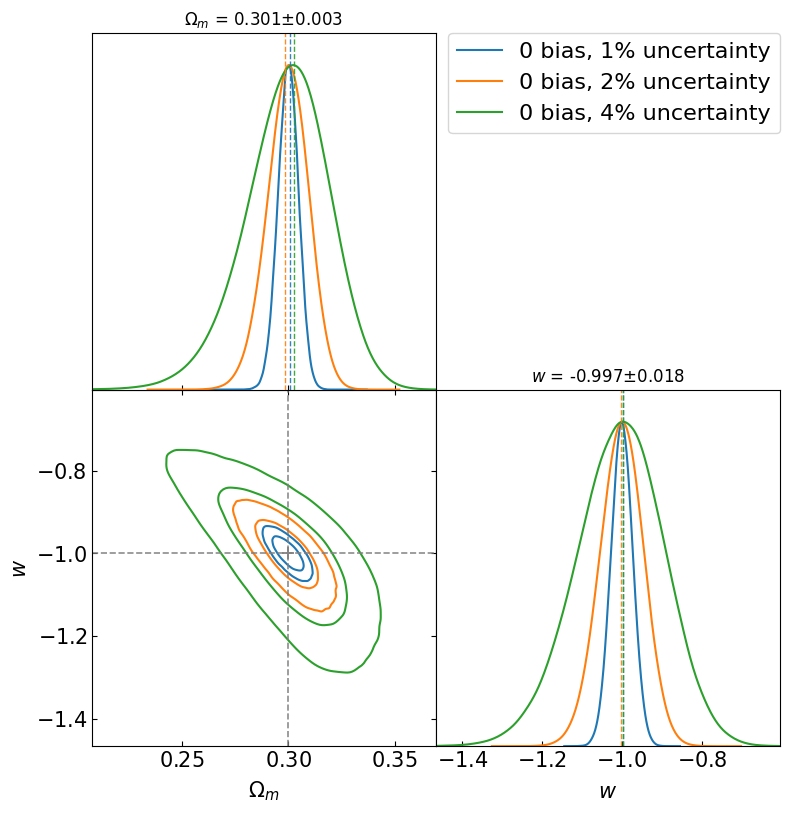

In [151]:
if __name__ == "__main__":
    base_dir = r'/home/astrodust/SG/sgl_cosmo/codes'
    param_names = [r'$\Omega_m$', r'$w$']

    # Option A: two parallel lists
    evo_list   = ["0_bias_0.01", "0_bias_0.02","0_bias_0.04"]
    prior_list = None

    plot_triangle_multi(
        base_dir=base_dir,
        param_names=param_names,
        evo_labels=evo_list,
        prior_labels=prior_list,
        output_folder=os.path.join(base_dir, "Results"),
        plot_name="triangle_2D_multi_0bias_wCDM.png",
        filled=False,
        add_markers=True
    )

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


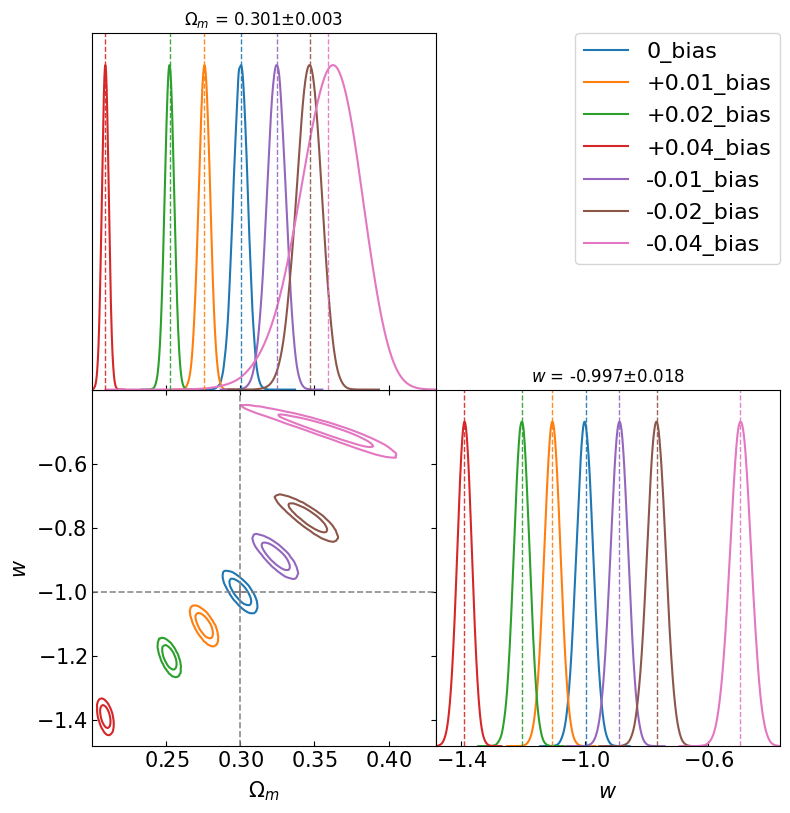

In [130]:
if __name__ == "__main__":
    base_dir = r'/home/astrodust/SG/sgl_cosmo/codes'
    param_names = [r'$\Omega_m$', r'$w$']

    # Option A: two parallel lists
    evo_list   = ["0_bias", "+0.01_bias","+0.02_bias", "+0.04_bias",
                 "-0.01_bias","-0.02_bias", "-0.04_bias"]
    prior_list = None

    plot_triangle_multi(
        base_dir=base_dir,
        param_names=param_names,
        evo_labels=evo_list,
        prior_labels=prior_list,
        output_folder=os.path.join(base_dir, "Results"),
        plot_name="triangle_2D_multi_bias_wCDM.png",
        filled=False,
        add_markers=True
    )

In [8]:

# if __name__ == "__main__":
#     cosmo = dict(H0=70.0, omega_m=0.3, omega_k=0.0, w0=-1.0, wa=0.0)  # ΛCDM
#     zl, zs1, zs2 = 0.5, 1.0, 2.0

#     R = galaxy_lens_distance_ratio(zl, zs1, **cosmo)
#     Ddt = time_delay_distance(zl, zs1, **cosmo)
#     beta = double_source_beta(zl, zs1, zs2, **cosmo)

#     print("R = Ds/Dls =", R)
#     print("D_dt [Mpc] =", Ddt)
#     print("beta_DSP   =", beta)

In [187]:
w_list = np.linspace(-2.0,0.0,201)[1:-1]
cosmo = dict(H0=70.0, omega_m=0.3, omega_k=0.0, w=-1.0)
zl01 = 0.8
zs01 = 1.0
zs02 = 1.5

R_ratio = []
Ddt_ratio = []
Doub_beta = []

for i in range(len(w_list)):
    cosmo_check = dict(H0=70.0, omega_m=0.3, omega_k=0.0, w=w_list[i]) 
    R_ratio.append(galaxy_lens_distance_ratio(zl01, zs01, **cosmo)/galaxy_lens_distance_ratio(zl01, zs01, **cosmo_check))
    Ddt_ratio.append(time_delay_distance_vec(zl01, zs01, **cosmo)/time_delay_distance_vec(zl01, zs01, **cosmo_check))
    # print(double_source_beta_vec(zl01, zs01, zs02, **cosmo_check))
    Doub_beta.append(double_source_beta_vec(zl01, zs01, zs02, **cosmo)/double_source_beta_vec(zl01, zs01, zs02, **cosmo_check))

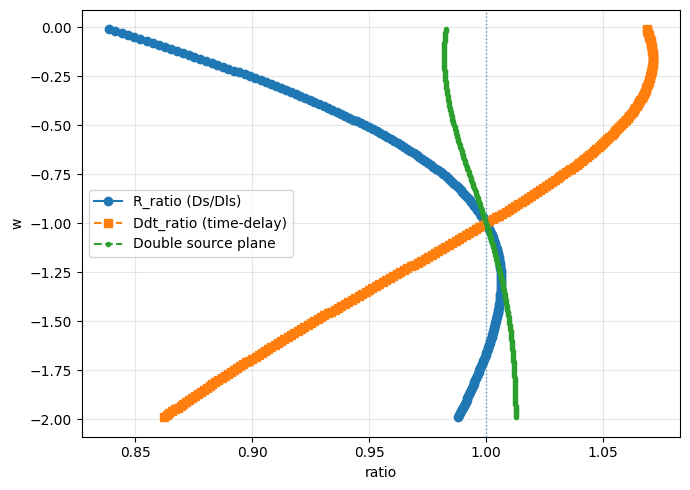

In [188]:
import numpy as np
import matplotlib.pyplot as plt

# 假设已有这三个等长数组：
# w_list, R_ratio, Ddt_ratio = ...

def prep_xy(x, y):
    """按 y 排序，并去除 NaN/inf。返回 x_sorted, y_sorted。"""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    idx = np.argsort(y)
    x, y = x[idx], y[idx]
    m = np.isfinite(x) & np.isfinite(y)
    return x[m], y[m]

x1, y1 = prep_xy(R_ratio,  w_list)   # R_ratio vs w
x2, y2 = prep_xy(Ddt_ratio, w_list)  # Ddt_ratio vs w
x3, y3 = prep_xy(Doub_beta, w_list)  # Ddt_ratio vs w

plt.figure(figsize=(7,5))
plt.plot(x1, y1, marker='o', linestyle='-', label='R_ratio (Ds/Dls)')
plt.plot(x2, y2, marker='s', linestyle='--', label='Ddt_ratio (time-delay)')
plt.plot(x3, y3, marker='.', linestyle='--', label='Double source plane')
plt.axvline(1.0, linestyle=':', linewidth=1, alpha=0.7)  # 可选：ratio=1 参考线

plt.xlabel('ratio')
plt.ylabel('w')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [171]:
w_list = np.linspace(-2.0,0.0,201)[1:-1]
cosmo = dict(H0=70.0, omega_m=0.3, omega_k=0.0, w=-1.0)
zl01 = 0.5
zs01 = 1.2
zs02 = 1.5

R_ratio = []
Ddt_ratio = []
Doub_beta = []

for i in range(len(w_list)):
    cosmo_check = dict(H0=70.0, omega_m=0.3, omega_k=0.0, w=w_list[i]) 
    R_ratio.append(galaxy_lens_distance_ratio(zl01, zs01, **cosmo)/galaxy_lens_distance_ratio(zl01, zs01, **cosmo_check))
    Ddt_ratio.append(time_delay_distance_vec(zl01, zs01, **cosmo)/time_delay_distance_vec(zl01, zs01, **cosmo_check))
    # print(double_source_beta_vec(zl01, zs01, zs02, **cosmo_check))
    Doub_beta.append(double_source_beta_vec(zl01, zs01, zs02, **cosmo)/double_source_beta_vec(zl01, zs01, zs02, **cosmo_check))

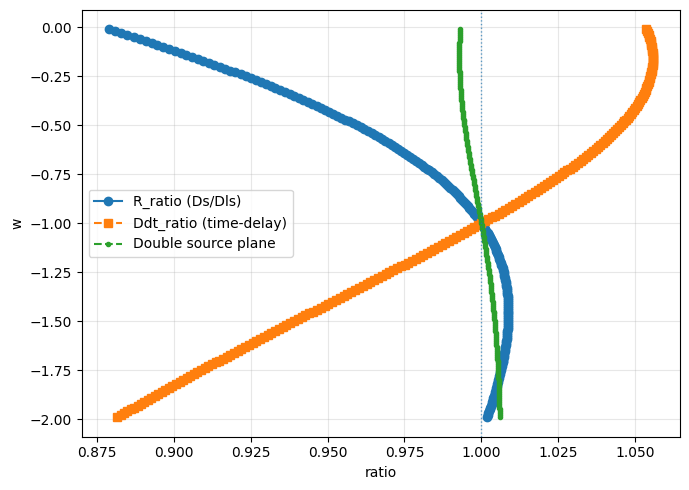

In [172]:
import numpy as np
import matplotlib.pyplot as plt

# 假设已有这三个等长数组：
# w_list, R_ratio, Ddt_ratio = ...

def prep_xy(x, y):
    """按 y 排序，并去除 NaN/inf。返回 x_sorted, y_sorted。"""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    idx = np.argsort(y)
    x, y = x[idx], y[idx]
    m = np.isfinite(x) & np.isfinite(y)
    return x[m], y[m]

x1, y1 = prep_xy(R_ratio,  w_list)   # R_ratio vs w
x2, y2 = prep_xy(Ddt_ratio, w_list)  # Ddt_ratio vs w
x3, y3 = prep_xy(Doub_beta, w_list)  # Ddt_ratio vs w

plt.figure(figsize=(7,5))
plt.plot(x1, y1, marker='o', linestyle='-', label='R_ratio (Ds/Dls)')
plt.plot(x2, y2, marker='s', linestyle='--', label='Ddt_ratio (time-delay)')
plt.plot(x3, y3, marker='.', linestyle='--', label='Double source plane')
plt.axvline(1.0, linestyle=':', linewidth=1, alpha=0.7)  # 可选：ratio=1 参考线

plt.xlabel('ratio')
plt.ylabel('w')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [44]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, List

# ====== 1) 包装：标量 R(zl,zs; cosmo) ======
def R_scalar(zl: float, zs: float, cosmo: Dict) -> float:
    # 只取 galaxy lens 的宇宙学部分：R = Ds/Dls
    return galaxy_lens_distance_ratio(float(zl), float(zs), **cosmo)

# ====== 2) 数值导数：∂ ln R / ∂ p ======
def dlnR_dp(zl: float, zs: float, cosmo: Dict, p: str,
            eps_rel: float = 1e-5, eps_abs: float = 1e-5) -> float:
    """
    对参数 p 求 ∂ ln R 的数值导数。
    对可为零或符号敏感的参量（如 w0, wa, omega_k），使用绝对步长；其余用相对步长。
    """
    cosmo_p = cosmo.copy()
    base = R_scalar(zl, zs, cosmo_p)
    if not np.isfinite(base) or base <= 0:
        return np.nan

    val = cosmo_p.get(p, None)
    # 选择步长
    if (val is None) or (abs(val) < 1e-12) or (p in ["w0", "wa", "omega_k"]):
        dp = eps_abs if p not in ["omega_m"] else max(eps_abs, 1e-6)
        p_minus, p_plus = (val - dp if val is not None else -dp), (val + dp if val is not None else dp)
    else:
        dp = abs(val) * eps_rel
        p_minus, p_plus = val - dp, val + dp

    # 边界防护（保证物理性）
    if p == "omega_m":
        p_minus = max(1e-6, p_minus); p_plus = max(2e-6, p_plus)
    if p == "w":   # 常数 w
        pass
    if p == "w0" or p == "wa":  # CPL
        pass
    if p == "omega_k":
        # 允许正负，但数值上别太极端
        p_minus = np.clip(p_minus, -0.5, 0.5)
        p_plus  = np.clip(p_plus,  -0.5, 0.5)

    # 中心差分
    cosmo_m = cosmo.copy(); cosmo_m[p] = p_minus
    cosmo_p2 = cosmo.copy(); cosmo_p2[p] = p_plus
    Rm = R_scalar(zl, zs, cosmo_m)
    Rp = R_scalar(zl, zs, cosmo_p2)
    if (Rm <= 0) or (Rp <= 0) or (not np.isfinite(Rm)) or (not np.isfinite(Rp)):
        return np.nan

    dlnR = (np.log(Rp) - np.log(Rm)) / (p_plus - p_minus)
    return float(dlnR)

# ====== 3) Fisher：单点 & 累积（保持不变，这里仅贴一遍方便对齐）======
def fisher_single(zl: float, zs: float, cosmo: Dict, params: List[str], sigma_frac: float) -> np.ndarray:
    """单个 (zl,zs) 的 Fisher（len(params) × len(params)）"""
    J = np.array([dlnR_dp(zl, zs, cosmo, p) for p in params], dtype=float)  # ∂lnR/∂p
    if not np.all(np.isfinite(J)):
        return np.zeros((len(params), len(params)))
    F = np.outer(J, J) / (sigma_frac**2)
    return F

def fisher_cumulative(zl_arr: np.ndarray, zs: float, cosmo: Dict, params: List[str], sigma_frac: float) -> np.ndarray:
    """把一个 zs 下所有 zl 的 Fisher 相加"""
    F = np.zeros((len(params), len(params)), dtype=float)
    for zl in zl_arr:
        if zl <= 0 or zl >= zs:
            continue
        F += fisher_single(float(zl), float(zs), cosmo, params, sigma_frac)
    return F

# ====== 4) zl 网格（保持不变）======
def zl_grid_for_zs(zs: float, dz: float = 0.004) -> np.ndarray:
    n = max(1, int(np.floor(zs / dz)))
    eps = 1e-6 * max(1.0, zs)
    return np.linspace(eps, zs - eps, n)

# ====== 5) 画“局部敏感度”曲线：S_p/sigma_lnR vs zl（8 条曲线/每个参数）======
def plot_local_sensitivity(zs_list, param, cosmo, sigma_frac=0.05, dz=0.004):
    """
    画 sensitivity ≡ |∂lnR/∂p| / σ_lnR 的曲线（越高越敏感）。
    每个 z_s 一条：横轴 z_l, 纵轴 sensitivity。
    """
    plt.figure(figsize=(8,5))
    for zs in zs_list:
        zls = zl_grid_for_zs(zs, dz=dz)
        sens = []
        for zl in zls:
            d = dlnR_dp(zl, zs, cosmo, param)
            if np.isfinite(d):
                sens.append(abs(d) / max(sigma_frac, 1e-30))
            else:
                sens.append(np.nan)
        plt.plot(zls, sens, label=f"z_s={zs:.1f}")

    plt.yscale('log')
    plt.xlabel(r"$z_l$")
    plt.ylabel(rf"Sensitivity: $|\partial \ln R/\partial {param}|/\sigma_{{\ln R}}$")
    plt.title(rf"Local sensitivity for {param}  (σ_R/R = {sigma_frac:.1%})")
    plt.grid(alpha=0.3)
    plt.legend(ncol=2)
    
    # —— 仅当限制的参数是 omega_m 时，加下限 0.1 —— 
    if param == "omega_m":
        ymin, ymax = plt.ylim()
        # 只修改下限，保留当前上限
        plt.ylim(bottom=0.5, top=max(ymax, 0.2)) 

    plt.tight_layout()
    plt.show()


# ====== 6) 画“累积边际化敏感度”曲线：1/σ_marg vs z_s ======
def plot_cumulative_marginalized(zs_list, params, cosmo, sigma_frac=0.05, dz=0.004, param_to_plot=None):
    """
    对每个 z_s，把 [0, z_s) 的所有 z_l Fisher 相加 => F。
    取协方差 C = F^{-1}，并画 1/sqrt(C_ii) 作为“边际化敏感度”（越高越敏感）。
    """
    zs_list = list(zs_list)
    if param_to_plot is not None:
        idx = params.index(param_to_plot)
        ys = []
        for zs in zs_list:
            F = fisher_cumulative(zl_grid_for_zs(zs, dz=dz), zs, cosmo, params, sigma_frac)
            if np.linalg.matrix_rank(F) < len(params):
                ys.append(np.nan)
            else:
                C = np.linalg.inv(F)
                sigma_i = np.sqrt(C[idx, idx])
                ys.append(1.0 / sigma_i if sigma_i > 0 else np.nan)
        plt.figure(figsize=(6,4))
        plt.plot(zs_list, ys, marker='o')
        plt.yscale('log')
        plt.xlabel(r"$z_s$")
        plt.ylabel(rf"Sensitivity: $1/\sigma({param_to_plot})$ (marginalized)")
        plt.title(rf"Cumulative marginalized sensitivity (σ_R/R = {sigma_frac:.1%})")
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        plt.figure(figsize=(7,5))
        for j, p in enumerate(params):
            ys = []
            for zs in zs_list:
                F = fisher_cumulative(zl_grid_for_zs(zs, dz=dz), zs, cosmo, params, sigma_frac)
                if np.linalg.matrix_rank(F) < len(params):
                    ys.append(np.nan)
                else:
                    C = np.linalg.inv(F)
                    sigma_j = np.sqrt(C[j, j])
                    ys.append(1.0 / sigma_j if sigma_j > 0 else np.nan)
            plt.plot(zs_list, ys, marker='o', label=p)
        plt.yscale('log')
        plt.xlabel(r"$z_s$")
        plt.ylabel("Sensitivity: $1/\\sigma(\\cdot)$  (marginalized)")
        plt.title(rf"Cumulative marginalized sensitivity vs $z_s$ (σ_R/R = {sigma_frac:.1%})")
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()





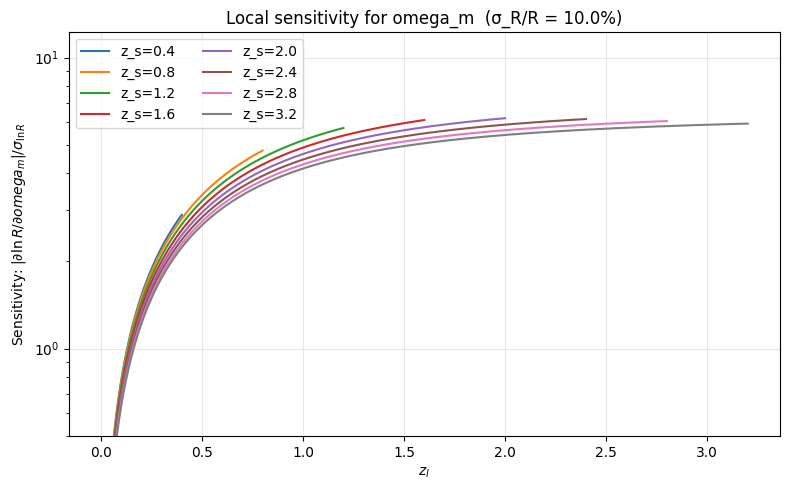

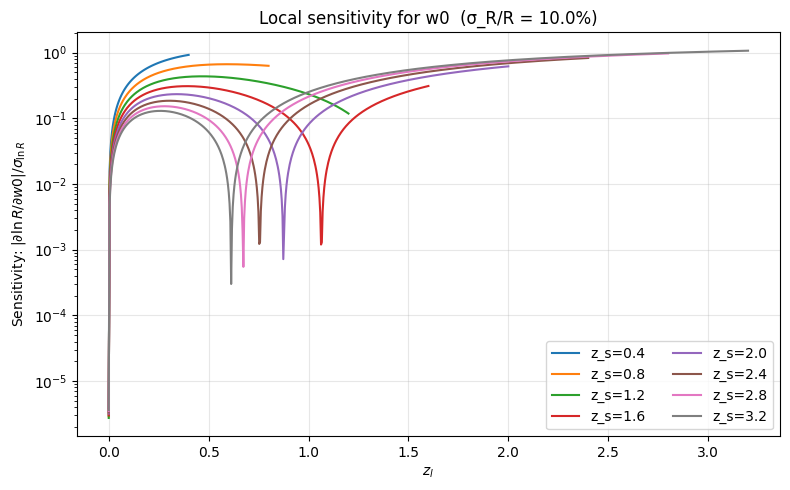

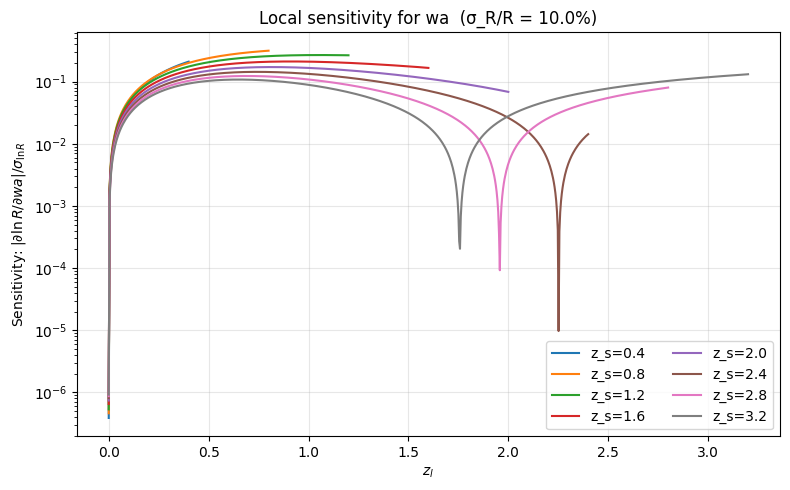

In [45]:
# ====== 7) 示例调用 ======
if __name__ == "__main__":
    # 选择模型：常数 w（传 w），或 CPL（不传 w，传 w0, wa）
    # 例：wCDM
    cosmo_wcdm = dict(H0=70.0, omega_m=0.3, omega_k=0.0, w=-1.0)
    # 例：CPL
    cosmo_cpl  = dict(H0=70.0, omega_m=0.3, omega_k=0.0, w0=-1.0, wa=0.0)

    zs_list = [0.4, 0.8, 1.2, 1.6, 2.0, 2.4, 2.8, 3.2]
    sigma_frac = 0.1   # 假设单个 R 的相对误差 5%，可改为 0.02 等
    dz = 0.004          # 你的网格步长

    # # —— 画“局部约束能力”曲线（每个参数各 8 条曲线）——
    # # 对 Ωm：
    plot_local_sensitivity(zs_list, param="omega_m", cosmo=cosmo_wcdm, sigma_frac=sigma_frac, dz=dz)
    # # 对 常数 w（若你用 wCDM）：
    # plot_local_sensitivity(zs_list, param="w",       cosmo=cosmo_wcdm, sigma_frac=sigma_frac, dz=dz)
    # # 或者对 CPL: w0, wa（若你用 CPL）
    plot_local_sensitivity(zs_list, param="w0",      cosmo=cosmo_cpl,  sigma_frac=sigma_frac, dz=dz)
    plot_local_sensitivity(zs_list, param="wa",      cosmo=cosmo_cpl,  sigma_frac=sigma_frac, dz=dz)

    # # —— 可选：画“累积边际化”约束（把一个 zs 下所有 zl 相加）——
    # # 多参数同时边际化（示例：Ωm 与 w）：
    # params_wcdm = ["omega_m", "w"]
    # plot_cumulative_marginalized(zs_list, params=params_wcdm, cosmo=cosmo_wcdm,
    #                              sigma_frac=sigma_frac, dz=dz, param_to_plot=None)
    # # 或只画某一个参数的累积边际化误差：
    # # plot_cumulative_marginalized(zs_list, params=params_wcdm, cosmo=cosmo_wcdm,
    # #                              sigma_frac=sigma_frac, dz=dz, param_to_plot="omega_m")

In [121]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, List

# ====== 1) 时延距离标量 ======
def Ddt_scalar(zl: float, zs: float, cosmo: Dict) -> float:
    return time_delay_distance(float(zl), float(zs), **cosmo)

# ====== 2) 数值导数：∂ ln D_dt / ∂ p ======
def dlnDdt_dp(zl: float, zs: float, cosmo: Dict, p: str,
              eps_rel: float = 1e-5, eps_abs: float = 1e-5) -> float:
    cosmo_p = cosmo.copy()
    base = Ddt_scalar(zl, zs, cosmo_p)
    if not np.isfinite(base) or base <= 0:
        return np.nan

    val = cosmo_p.get(p, None)
    # 步长
    if (val is None) or (abs(val) < 1e-12) or (p in ["w0", "wa", "omega_k"]):
        dp = eps_abs if p not in ["omega_m", "H0"] else max(eps_abs, 1e-6)
        p_minus, p_plus = (val - dp if val is not None else -dp), (val + dp if val is not None else dp)
    else:
        dp = abs(val) * eps_rel
        p_minus, p_plus = val - dp, val + dp

    # 物理边界
    if p == "omega_m":
        p_minus = max(1e-6, p_minus); p_plus = max(2e-6, p_plus)
    if p == "omega_k":
        p_minus = np.clip(p_minus, -0.5, 0.5)
        p_plus  = np.clip(p_plus,  -0.5, 0.5)
    if p == "H0":
        p_minus = max(1.0, p_minus); p_plus = max(2.0, p_plus)

    # 中心差分
    cosmo_m = cosmo.copy();  cosmo_m[p]  = p_minus
    cosmo_p2 = cosmo.copy(); cosmo_p2[p] = p_plus
    Dm = Ddt_scalar(zl, zs, cosmo_m)
    Dp = Ddt_scalar(zl, zs, cosmo_p2)
    if (Dm <= 0) or (Dp <= 0) or (not np.isfinite(Dm)) or (not np.isfinite(Dp)):
        return np.nan

    return float((np.log(Dp) - np.log(Dm)) / (p_plus - p_minus))

# ====== helper：确保 H0 在参数列表里，并返回去重后的顺序表 ======
def _with_H0(params: List[str]) -> List[str]:
    seen = set()
    out = []
    for p in list(params) + ["H0"]:
        if p not in seen:
            out.append(p); seen.add(p)
    return out

# ====== 3) Fisher：单点 & 累积（始终把 H0 纳入）======
def fisher_single(zl: float, zs: float, cosmo: Dict, params: List[str], sigma_frac: float):
    """
    返回 (F, params_eff)：
      - F: (len(params_eff) x len(params_eff)) Fisher 矩阵
      - params_eff: 实际使用的参数顺序（原 params + 'H0'，去重）
    """
    params_eff = _with_H0(params)
    J = np.array([dlnDdt_dp(zl, zs, cosmo, p) for p in params_eff], dtype=float)  # ∂ln D_dt/∂p
    if not np.all(np.isfinite(J)):
        return np.zeros((len(params_eff), len(params_eff))), params_eff
    F = np.outer(J, J) / (sigma_frac**2)
    return F, params_eff

def fisher_cumulative(zl_arr: np.ndarray, zs: float, cosmo: Dict, params: List[str], sigma_frac: float):
    """
    把一个 z_s 下所有 z_l 的 Fisher 相加。
    返回 (F, params_eff)。
    """
    params_eff = _with_H0(params)
    F = np.zeros((len(params_eff), len(params_eff)), dtype=float)
    for zl in zl_arr:
        if zl <= 0 or zl >= zs:
            continue
        F_k, _ = fisher_single(float(zl), float(zs), cosmo, params_eff, sigma_frac)
        F += F_k
    return F, params_eff

# ====== 4) zl 网格 ======
def zl_grid_for_zs(zs: float, dz: float = 0.004) -> np.ndarray:
    n = max(1, int(np.floor(zs / dz)))
    eps = 1e-6 * max(1.0, zs)
    return np.linspace(eps, zs - eps, n)

# ====== 5) 局部敏感度：支持直接画 H0 ======
def plot_local_sensitivity(zs_list, param, cosmo, sigma_frac=0.05, dz=0.004):
    """
    sensitivity ≡ |∂ln D_dt/∂p| / σ_lnD；σ_lnD≈sigma_frac。
    """
    plt.figure(figsize=(8,5))
    for zs in zs_list:
        zls = zl_grid_for_zs(zs, dz=dz)
        sens = []
        for zl in zls:
            d = dlnDdt_dp(zl, zs, cosmo, param)
            sens.append(abs(d) / max(sigma_frac, 1e-30) if np.isfinite(d) else np.nan)
        plt.plot(zls, sens, label=f"z_s={zs:.1f}")

    plt.yscale('log')
    plt.xlabel(r"$z_l$")
    plt.ylabel(rf"Sensitivity: $|\partial \ln D_{{\Delta t}}/\partial {param}|\,/\,\sigma_{{\ln D}}$")
    plt.title(rf"Time-delay: Local sensitivity for {param}  (σ$_{{D_\Delta t}}$/D$_{{\Delta t}}$ = {sigma_frac:.1%})")
    plt.grid(alpha=0.3)
    plt.legend(ncol=2)

    if param == "omega_m":
        ymin, ymax = plt.ylim()
        plt.ylim(bottom=0.5, top=max(ymax, 0.5))

    plt.tight_layout()
    plt.show()

# ====== 6) 累积边际化敏感度：自动把 H0 纳入边际化 ======
def plot_cumulative_marginalized(zs_list, params, cosmo, sigma_frac=0.05, dz=0.004, param_to_plot=None):
    """
    对每个 z_s，把 [0,z_s) 的 z_l Fisher 累加，C=F^{-1}，画 1/sqrt(C_ii)。
    始终把 H0 纳入 params 并边际化。
    """
    zs_list = list(zs_list)

    if param_to_plot is not None:
        ys = []
        for zs in zs_list:
            F, params_eff = fisher_cumulative(zl_grid_for_zs(zs, dz=dz), zs, cosmo, params, sigma_frac)
            if np.linalg.matrix_rank(F) < len(params_eff) or (param_to_plot not in params_eff):
                ys.append(np.nan)
            else:
                C = np.linalg.inv(F)
                idx = params_eff.index(param_to_plot)
                sigma_i = np.sqrt(C[idx, idx])
                ys.append(1.0 / sigma_i if sigma_i > 0 else np.nan)
        plt.figure(figsize=(6,4))
        plt.plot(zs_list, ys, marker='o')
        plt.yscale('log')
        plt.xlabel(r"$z_s$")
        plt.ylabel(rf"Sensitivity: $1/\sigma({param_to_plot})$ (marginalized)")
        plt.title(rf"Time-delay: Cumulative marginalized sensitivity (σ$_{{D_\Delta t}}$/D$_{{\Delta t}}$ = {sigma_frac:.1%})")
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        plt.figure(figsize=(7,5))
        # 这里的 params_eff 在不同 zs 可变，但一般稳定；用第一个 zs 确定图例顺序
        F0, params_eff0 = fisher_cumulative(zl_grid_for_zs(zs_list[0], dz=dz), zs_list[0], cosmo, params, sigma_frac)
        for j, p in enumerate(params_eff0):
            ys = []
            for zs in zs_list:
                F, params_eff = fisher_cumulative(zl_grid_for_zs(zs, dz=dz), zs, cosmo, params, sigma_frac)
                if (np.linalg.matrix_rank(F) < len(params_eff)) or (p not in params_eff):
                    ys.append(np.nan)
                else:
                    C = np.linalg.inv(F)
                    jj = params_eff.index(p)
                    sigma_j = np.sqrt(C[jj, jj])
                    ys.append(1.0 / sigma_j if sigma_j > 0 else np.nan)
            plt.plot(zs_list, ys, marker='o', label=p)

        plt.yscale('log')
        plt.xlabel(r"$z_s$")
        plt.ylabel("Sensitivity: $1/\\sigma(\\cdot)$  (marginalized)")
        plt.title(rf"Time-delay: Cumulative marginalized sensitivity vs $z_s$ (σ$_{{D_\Delta t}}$/D$_{{\Delta t}}$ = {sigma_frac:.1%})")
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()


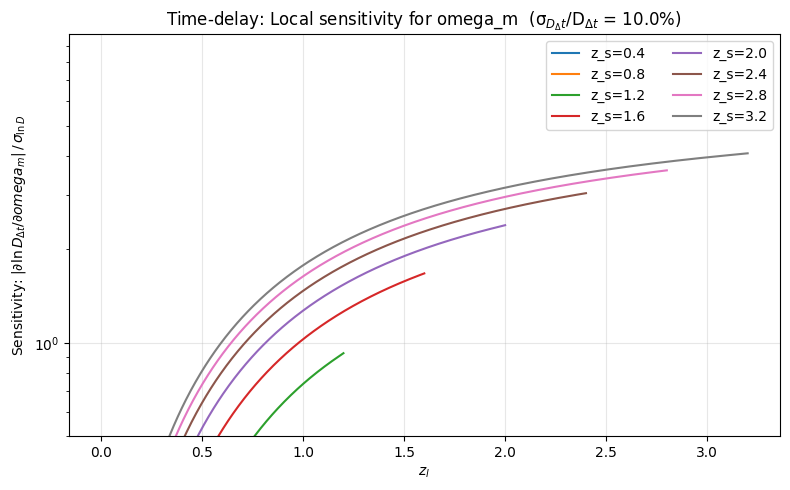

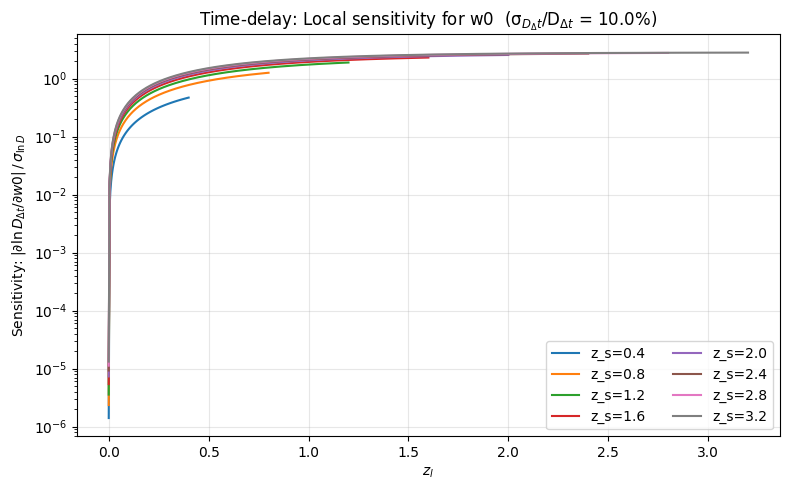

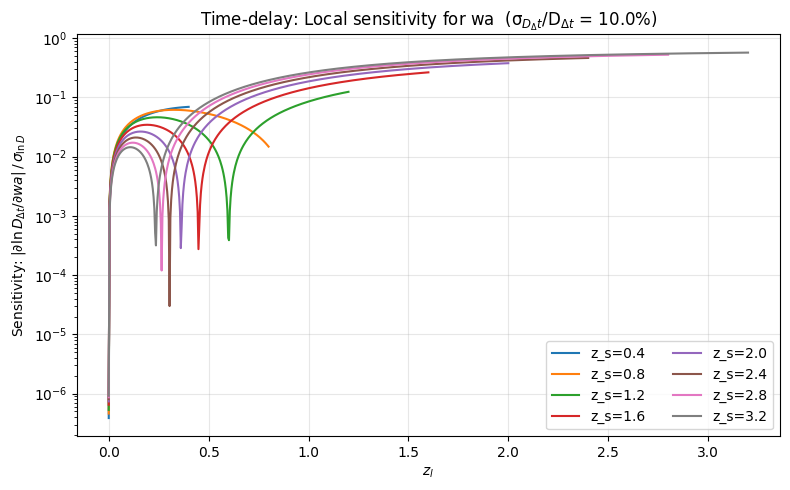

In [126]:
# ====== 7) 示例调用 ======
if __name__ == "__main__":
    # 选择模型：常数 w（传 w），或 CPL（不传 w，传 w0, wa）
    # 例：wCDM
    cosmo_wcdm = dict(H0=70.0, omega_m=0.3, omega_k=0.0, w=-1.0)
    # 例：CPL
    cosmo_cpl  = dict(H0=70.0, omega_m=0.3, omega_k=0.0, w0=-1.0, wa=0.0)

    zs_list = [0.4, 0.8, 1.2, 1.6, 2.0, 2.4, 2.8, 3.2]
    sigma_frac = 0.1   # 假设单个 R 的相对误差 5%，可改为 0.02 等
    dz = 0.004          # 你的网格步长

    # # —— 画“局部约束能力”曲线（每个参数各 8 条曲线）——
    # # 对 Ωm：
    plot_local_sensitivity(zs_list, param="omega_m", cosmo=cosmo_wcdm, sigma_frac=sigma_frac, dz=dz)
    # # 对 常数 w（若你用 wCDM）：
    # plot_local_sensitivity(zs_list, param="w",       cosmo=cosmo_wcdm, sigma_frac=sigma_frac, dz=dz)
    # # 或者对 CPL: w0, wa（若你用 CPL）
    plot_local_sensitivity(zs_list, param="w0",      cosmo=cosmo_cpl,  sigma_frac=sigma_frac, dz=dz)
    plot_local_sensitivity(zs_list, param="wa",      cosmo=cosmo_cpl,  sigma_frac=sigma_frac, dz=dz)

    # # —— 可选：画“累积边际化”约束（把一个 zs 下所有 zl 相加）——
    # # 多参数同时边际化（示例：Ωm 与 w）：
    # params_wcdm = ["omega_m", "w"]
    # plot_cumulative_marginalized(zs_list, params=params_wcdm, cosmo=cosmo_wcdm,
    #                              sigma_frac=sigma_frac, dz=dz, param_to_plot=None)
    # 或只画某一个参数的累积边际化误差：
    # plot_cumulative_marginalized(zs_list, params=params_wcdm, cosmo=cosmo_wcdm,
    #                              sigma_frac=sigma_frac, dz=dz, param_to_plot="omega_m")

In [133]:
from astropy.table import Table
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, List

# === 读取数据 ===
LSSTa_lens = Table.read(r"/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/LSSTa_sim_l3.fits")
zl_all = np.asarray(LSSTa_lens["zl"], dtype=float)
zs_all = np.asarray(LSSTa_lens["zs"], dtype=float)

# 你的 R/敏感度相关函数（保持你现有实现）
def R_scalar(zl: float, zs: float, cosmo: Dict) -> float:
    return galaxy_lens_distance_ratio(float(zl), float(zs), **cosmo)

def dlnR_dp(zl: float, zs: float, cosmo: Dict, p: str,
            eps_rel: float = 1e-5, eps_abs: float = 1e-5) -> float:
    cosmo_p = cosmo.copy()
    base = R_scalar(zl, zs, cosmo_p)
    if not np.isfinite(base) or base <= 0:
        return np.nan

    val = cosmo_p.get(p, None)
    if (val is None) or (abs(val) < 1e-12) or (p in ["w0", "wa", "omega_k"]):
        dp = eps_abs if p not in ["omega_m"] else max(eps_abs, 1e-6)
        p_minus, p_plus = (val - dp if val is not None else -dp), (val + dp if val is not None else dp)
    else:
        dp = abs(val) * eps_rel
        p_minus, p_plus = val - dp, val + dp

    if p == "omega_m":
        p_minus = max(1e-6, p_minus); p_plus = max(2e-6, p_plus)
    if p == "omega_k":
        p_minus = np.clip(p_minus, -0.5, 0.5)
        p_plus  = np.clip(p_plus,  -0.5, 0.5)

    cosmo_m = cosmo.copy(); cosmo_m[p] = p_minus
    cosmo_p2 = cosmo.copy(); cosmo_p2[p] = p_plus
    Rm = R_scalar(zl, zs, cosmo_m)
    Rp = R_scalar(zl, zs, cosmo_p2)
    if (Rm <= 0) or (Rp <= 0) or (not np.isfinite(Rm)) or (not np.isfinite(Rp)):
        return np.nan

    dlnR = (np.log(Rp) - np.log(Rm)) / (p_plus - p_minus)
    return float(dlnR)

def zl_grid_for_zs(zs: float, dz: float = 0.004) -> np.ndarray:
    n = max(1, int(np.floor(zs / dz)))
    eps = 1e-6 * max(1.0, zs)
    return np.linspace(eps, zs - eps, n)

# === 组合图：local sensitivity（左轴，log） + 直方图（右轴，log） ===
def plot_hist_and_local_sensitivity(
    zs_list,
    param: str,
    cosmo: Dict,
    sigma_frac: float = 0.05,
    dz: float = 0.004,
    bins: np.ndarray = np.linspace(0, 3, 31),
    title: str = None
):
    zs_list = list(zs_list)

    fig, ax = plt.subplots(figsize=(9, 6))

    # 1) 左轴：不同 z_s 下的 local sensitivity 曲线
    cmap = plt.cm.viridis(np.linspace(0.2, 0.9, len(zs_list)))
    for c, zs in zip(cmap, zs_list):
        zls = zl_grid_for_zs(zs, dz=dz)
        sens = []
        for zl in zls:
            d = dlnR_dp(zl, zs, cosmo, param)
            sens.append(abs(d) / max(sigma_frac, 1e-30) if np.isfinite(d) else np.nan)
        sens = np.array(sens, dtype=float)
        ax.plot(zls, sens, lw=1.8, color=c, label=fr"$z_s={zs:.1f}$", zorder=3)

    ax.set_xlim(bins[0], bins[-1])
    ax.set_ylim(1.0*10**-5,1.0*10**1.5)
    ax.set_yscale('log')
    ax.set_xlabel(r"Redshift $z$")
    ax.set_ylabel(rf"Sensitivity $|\partial \ln R / \partial {param}|/\sigma_{{\ln R}}$ (dimensionless)")
    ax.grid(alpha=0.3, which='both', axis='both')

    # 2) 右轴：直方图（zl 与 zs）
    ax2 = ax.twinx()
    ax2.set_yscale('log')
    ax2.set_ylim(0.,1.0*10**6)

    # 为了在 log 轴上避免 0 计数引发问题，用 np.histogram + stairs，并给一个很小的地板值
    EPS = 1e-2
    cnt_zl, _ = np.histogram(zl_all, bins=bins)
    cnt_zs, _ = np.histogram(zs_all, bins=bins)

    # 使用 stairs（Matplotlib>=3.4）；如果你的版本没有 stairs，可改用 ax2.hist(..., histtype='step')
    ax2.stairs(np.maximum(cnt_zl, EPS), bins, label=r"$z_l$ histogram", lw=1.8, linestyle='-', color='tab:blue', zorder=1)
    ax2.stairs(np.maximum(cnt_zs, EPS), bins, label=r"$z_s$ histogram", lw=1.8, linestyle='--', color='tab:orange', zorder=1)

    ax2.set_ylabel("Number count")

    # 图例：左边为 sensitivity 曲线，右边为直方图
    leg1 = ax.legend(title=fr"Sensitivity (param = {param})", ncol=2, loc='lower right', fontsize=15, frameon=True)
    leg2 = ax2.legend(title="Histograms", loc='upper right', fontsize=15, frameon=True)

    # 标题
    if title is None:
        title = rf"Sensitivity vs. $z_l$ (left, log)  &  Hist of $z_l/z_s$ (right, log)   [σ_R/R = {sigma_frac:.1%}]"
    # ax.set_title(title)

    plt.tight_layout()
    plt.show()



/tmp/ipykernel_303597/773120258.py:86: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax2.set_ylim(0.,1.0*10**6)


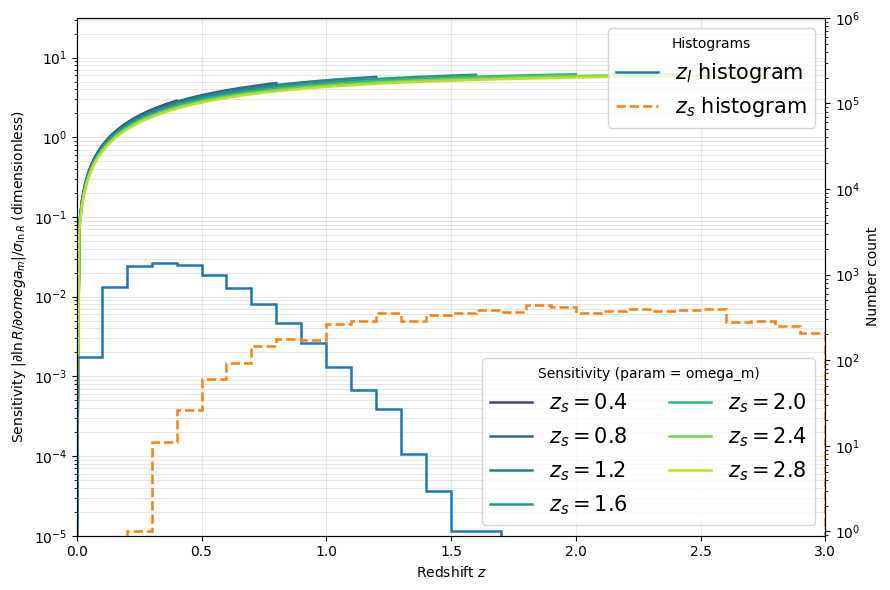

In [134]:
# ====== 示例调用 ======
# 这里放你要用的宇宙学参数；按需修改
cosmo = dict(H0=70.0, omega_m=0.3, w0=-1.0, wa=0.0, omega_k=0.0)

# 画 omega_m 的 local sensitivity + 直方图
plot_hist_and_local_sensitivity(
    zs_list=[0.4, 0.8, 1.2, 1.6, 2.0, 2.4, 2.8],
    param="omega_m",
    cosmo=cosmo,
    sigma_frac=0.1,
    dz=0.01,  # 适当加大步长可加快计算
    bins=np.linspace(0, 3, 31)
)


/tmp/ipykernel_303597/773120258.py:86: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax2.set_ylim(0.,1.0*10**6)


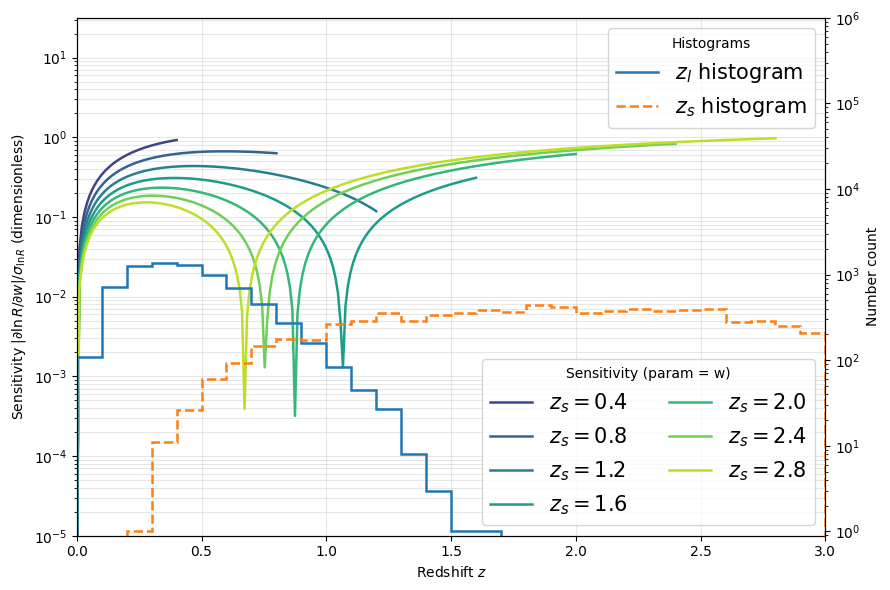

In [135]:
# ====== 示例调用 ======
# 这里放你要用的宇宙学参数；按需修改
cosmo = dict(H0=70.0, omega_m=0.3, w=-1.)

# 画 omega_m 的 local sensitivity + 直方图
plot_hist_and_local_sensitivity(
    zs_list=[0.4, 0.8, 1.2, 1.6, 2.0, 2.4, 2.8],
    param="w",
    cosmo=cosmo,
    sigma_frac=0.1,
    dz=0.01,  # 适当加大步长可加快计算
    bins=np.linspace(0, 3, 31)
)


/tmp/ipykernel_303597/773120258.py:86: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax2.set_ylim(0.,1.0*10**6)


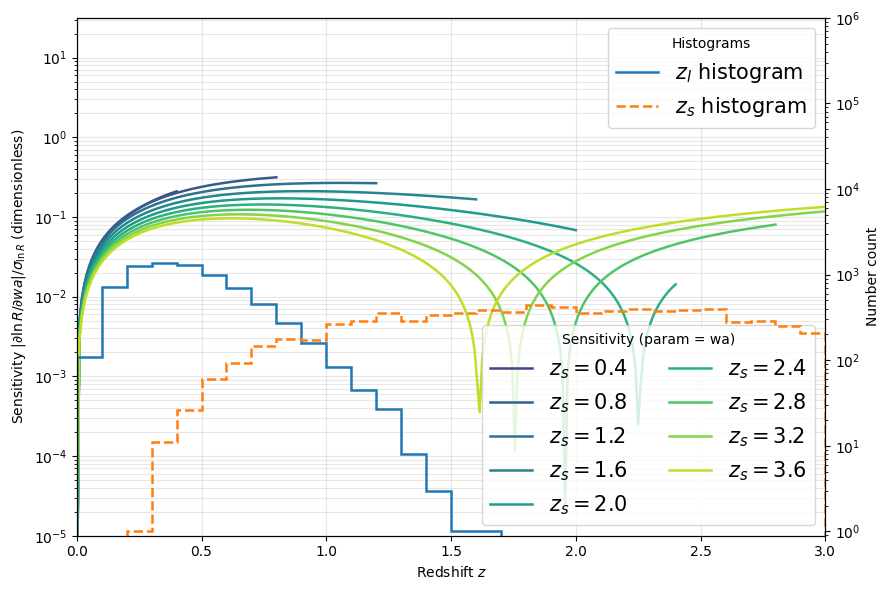

In [145]:
# ====== 示例调用 ======
# 这里放你要用的宇宙学参数；按需修改
cosmo = dict(H0=70.0, omega_m=0.3, w0=-1.0, wa=0.0, omega_k=0.0)

# 画 omega_m 的 local sensitivity + 直方图
plot_hist_and_local_sensitivity(
    zs_list=[0.4, 0.8, 1.2, 1.6, 2.0, 2.4, 2.8,3.2,3.6],
    param="wa",
    cosmo=cosmo,
    sigma_frac=0.1,
    dz=0.01,  # 适当加大步长可加快计算
    bins=np.linspace(0, 3, 31)
)


/tmp/ipykernel_303597/773120258.py:86: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax2.set_ylim(0.,1.0*10**6)


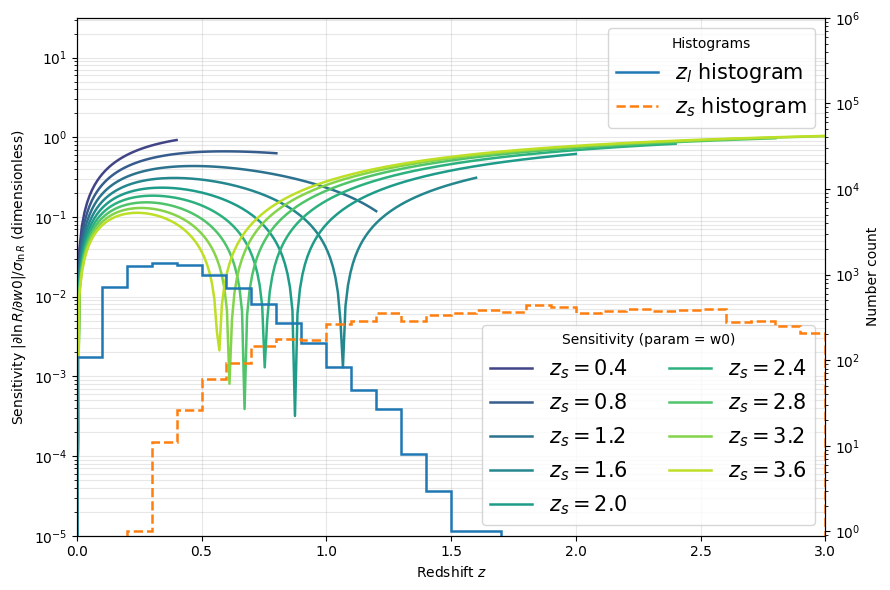

In [146]:
# ====== 示例调用 ======
# 这里放你要用的宇宙学参数；按需修改
cosmo = dict(H0=70.0, omega_m=0.3, w0=-1.0, wa=0.0, omega_k=0.0)

# 画 omega_m 的 local sensitivity + 直方图
plot_hist_and_local_sensitivity(
    zs_list=[0.4, 0.8, 1.2, 1.6, 2.0, 2.4, 2.8,3.2,3.6],
    param="w0",
    cosmo=cosmo,
    sigma_frac=0.1,
    dz=0.01,  # 适当加大步长可加快计算
    bins=np.linspace(0, 3, 31)
)


In [142]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- Cosmology helpers (常用 wCDM / CPL；与 H0 无关，因为 χ 与 E 无单位) ----------
def _rho_de_evol(z, cosmo):
    # 常数 w 或 CPL
    if cosmo.get("w", None) is not None:
        w = cosmo["w"]
        return (1.0 + z)**(3.0*(1.0 + w))
    w0 = cosmo.get("w0", -1.0)
    wa = cosmo.get("wa",  0.0)
    return (1.0 + z)**(3.0*(1.0 + w0 + wa)) * np.exp(-3.0*wa * z/(1.0+z))

def _E(z, cosmo):
    Om = cosmo.get("omega_m", 0.3)
    Ok = cosmo.get("omega_k", 0.0)
    Or = cosmo.get("omega_r", 0.0)
    Ode0 = 1.0 - Om - Ok - Or
    return np.sqrt(Om*(1+z)**3 + Or*(1+z)**4 + Ok*(1+z)**2 + Ode0*_rho_de_evol(z, cosmo))

def _dE2_dp(z, cosmo, param="w"):
    """∂(E^2)/∂p；只对 DE 项有 p 相关（除非是 omega_*）。"""
    Om = cosmo.get("omega_m", 0.3)
    Ok = cosmo.get("omega_k", 0.0)
    Or = cosmo.get("omega_r", 0.0)
    Ode0 = 1.0 - Om - Ok - Or
    if param == "w":  # 常数 w
        if cosmo.get("w", None) is None:
            return 0.0
        return Ode0 * _rho_de_evol(z, cosmo) * (3.0*np.log(1.0+z))
    if param == "w0":
        return Ode0 * _rho_de_evol(z, cosmo) * (3.0*np.log(1.0+z))
    if param == "wa":
        return Ode0 * _rho_de_evol(z, cosmo) * (3.0*np.log(1.0+z) - 3.0*z/(1.0+z))
    if param == "omega_m":
        return (1.0 + z)**3
    if param == "omega_k":
        return (1.0 + z)**2
    if param == "omega_r":
        return (1.0 + z)**4
    # 其它参数默认 0
    return 0.0

# ---------- Integrators（无 SciPy 时用梯形规则） ----------
try:
    from scipy.integrate import quad
    _HAS_SCIPY = True
except Exception:
    _HAS_SCIPY = False

def _integrate(func, a, b, args=(), N=4097):
    if _HAS_SCIPY:
        val, _ = quad(lambda x: func(x, *args), a, b, epsrel=1e-8, epsabs=0.0, limit=256)
        return val
    xs = np.linspace(a, b, N)
    ys = func(xs, *args)
    return np.trapz(ys, xs)

# ---------- χ(z), ∂χ/∂p, f(z)= (∂χ/∂p)/χ, 以及 f/χ ----------
def chi_of_z(z, cosmo):
    return _integrate(lambda zp, _cosmo: 1.0/_E(zp, _cosmo), 0.0, float(z), args=(cosmo,))

def dchi_dp(z, cosmo, param="w"):
    def integrand(zp, _cosmo, _param):
        E  = _E(zp, _cosmo)
        dE2 = _dE2_dp(zp, _cosmo, _param)
        dE = 0.5 * dE2 / E
        return dE / (E**2)   # = (∂E)/E^2
    val = _integrate(lambda zp, _cosmo, _param: integrand(zp, _cosmo, _param),
                     0.0, float(z), args=(cosmo, param))
    return -val

def f_of_z(z, cosmo, param="w"):
    chi = chi_of_z(z, cosmo)
    if not np.isfinite(chi) or chi <= 0:
        return np.nan
    return dchi_dp(z, cosmo, param) / chi

def f_over_chi(z, cosmo, param="w"):
    chi = chi_of_z(z, cosmo)
    if not np.isfinite(chi) or chi <= 0:
        return np.nan
    return dchi_dp(z, cosmo, param) / (chi*chi)

# ---------- 画 f(z_l)/χ(z_l) 与 f(z_s)/χ(z_s) 随 z 的变化 ----------
# ---------- 画 f(z)（分别标注 lens/source 的同一函数） ----------
def plot_f(curve_max_z=3.0, cosmo=None, param="w", nz=400):
    """
    画 f(z) = (∂χ/∂p)/χ 随 z 的变化。
    """
    if cosmo is None:
        cosmo = dict(omega_m=0.3, omega_k=0.0, w=-1.0)

    zgrid = np.linspace(1e-6, curve_max_z, nz)
    fgrid = np.array([f_of_z(z, cosmo, param) for z in zgrid])

    plt.figure(figsize=(7,5))
    plt.plot(zgrid, fgrid, label=r"$f(z)$ (as lens)")
    plt.plot(zgrid, fgrid, ls='--', label=r"$f(z)$ (as source)")
    plt.axhline(0.0, ls=":", lw=1)
    plt.xlabel("redshift z")
    plt.ylabel(r"$f(z)=\frac{\partial_p d(z)}{d(z)}$")
    plt.title(r"$f(z)$ vs $z$  (param = {})".format(param))
    plt.grid(alpha=0.3); plt.legend()
    plt.tight_layout(); plt.show()

# ============ 辅助：三点抛物线细化极值位置 ============
def _parabolic_vertex(xm, x0, xp, ym, y0, yp):
    # 在 (xm,ym), (x0,y0), (xp,yp) 上拟合 y = ax^2 + bx + c，返回顶点 x_v, y_v
    denom = (ym - 2*y0 + yp)
    if abs(denom) < 1e-300:
        return x0, y0
    xv = x0 + 0.5 * ( (ym - yp) / denom ) * (xp - xm) / 2.0
    # 为防止越界，夹在 [xm, xp] 内
    xv = max(min(xv, xp), xm)
    # 估计 y_v
    a = ( (yp - y0)/(xp - x0) - (y0 - ym)/(x0 - xm) ) / (xp - xm)
    b = (y0 - ym)/(x0 - xm) - a*(x0 + xm)
    c = y0 - a*x0**2 - b*x0
    yv = a*xv**2 + b*xv + c
    return xv, yv

def _find_extrema(zgrid, ygrid):
    """
    返回极值列表：[{'kind':'max'/'min','z':..., 'y':...}, ...]
    使用梯度符号变化 + 抛物线细化。
    """
    z = np.asarray(zgrid, float)
    y = np.asarray(ygrid, float)
    dy = np.gradient(y, z)
    res = []
    # 极大: dy 前正后负；极小: dy 前负后正
    idx_max = np.where((dy[:-1] > 0) & (dy[1:] < 0))[0] + 1
    idx_min = np.where((dy[:-1] < 0) & (dy[1:] > 0))[0] + 1
    for kind, idxs in (("max", idx_max), ("min", idx_min)):
        for i in idxs:
            if i == 0 or i == len(z)-1:  # 跳过端点
                continue
            zm, z0, zp = z[i-1], z[i], z[i+1]
            ym, y0, yp = y[i-1], y[i], y[i+1]
            xv, yv = _parabolic_vertex(zm, z0, zp, ym, y0, yp)
            res.append(dict(kind=kind, z=float(xv), y=float(yv)))
    # 按 z 排序
    res.sort(key=lambda d: d["z"])
    return res

# ============ 角径距 D_A(z)：平直/非平直通用 ============
C_KMS = 299792.458  # km/s

def _Sk(x, Ok0):
    if abs(Ok0) < 1e-12:
        return x
    if Ok0 > 0:
        return np.sinh(x)
    else:
        return np.sin(x)

def D_A_of_z(z, cosmo, H0=70.0):
    """角径距 D_A(z) [Mpc]；使用 χ 和曲率函数 S_k。"""
    Ok0 = cosmo.get("omega_k", 0.0)
    chi = chi_of_z(z, cosmo)
    if abs(Ok0) < 1e-12:
        DM = (C_KMS / H0) * chi
    else:
        sOk = np.sqrt(abs(Ok0))
        DM  = (C_KMS / H0) * _Sk(sOk * chi, Ok0) / sOk
    return DM / (1.0 + z)

# ============ 1) 仅画 f(z)，并标出极值 ============
def plot_f_with_extrema(
    max_z=3.0,
    cosmo=None,
    param="w",
    nz=1000,
    fs_label=16,   # x/y 轴标签字体
    fs_tick=14,    # 坐标刻度字体
    fs_title=18,   # 标题字体
    fs_legend=16   # 图例字体
):
    if cosmo is None:
        cosmo = dict(omega_m=0.3, omega_k=0.0, w=-1.0)

    zgrid = np.linspace(1e-6, max_z, nz)
    fgrid = np.array([f_of_z(z, cosmo, param) for z in zgrid])
    extrema = _find_extrema(zgrid, fgrid)

    plt.figure(figsize=(8,6))
    plt.plot(zgrid, fgrid, label=rf"$f(z)=\partial_{{{param}}}d(z)/d(z)$", lw=1.8)

    # 标极值
    for e in extrema:
        m = "v" if e["kind"] == "max" else "^"
        plt.plot(e["z"], e["y"], marker=m, ms=8,
                 label=f"{e['kind']} at z={e['z']:.3f}")

    plt.axhline(0, ls=":", lw=1.2, color="0.6")
    plt.xlabel("redshift z", fontsize=fs_label)
    plt.ylabel(r"$f(z)$", fontsize=fs_label)
    plt.title(r"$f(z)$ and its extrema  (param = {})".format(param), fontsize=fs_title)

    ax = plt.gca()
    ax.tick_params(axis='both', which='major', labelsize=fs_tick)
    ax.grid(alpha=0.3)

    leg = plt.legend(fontsize=fs_legend, title_fontsize=fs_legend, frameon=True)
    plt.tight_layout()
    plt.show()

    # # 打印列表
    # if len(extrema) == 0:
    #     print("[f(z)] no internal extrema in (0, {:.2f}]".format(max_z))
    # else:
    #     for e in extrema:
    #         print("[f(z)] {:>3s} at z={:.6f},  f={:.6e}".format(e["kind"], e["z"], e["y"]))


# ============ 2) 画 D_A(z)，并标出峰值 ============
def plot_DA_with_peak(max_z=5.0, cosmo=None, H0=70.0, nz=1200):
    if cosmo is None:
        cosmo = dict(omega_m=0.3, omega_k=0.0, w=-1.0)

    zgrid = np.linspace(1e-6, max_z, nz)
    DAg   = np.array([D_A_of_z(z, cosmo, H0) for z in zgrid])
    extrema = _find_extrema(zgrid, DAg)

    plt.figure(figsize=(7,5))
    plt.plot(zgrid, DAg, label=r"$D_A(z)$")
    # 角径距常见只有一个最大值；把所有极值标出来也没问题
    for e in extrema:
        m = "v" if e["kind"]=="max" else "^"
        plt.plot(e["z"], e["y"], marker=m, ms=7,
                 label=f"{e['kind']} at z={e['z']:.3f}")
    plt.xlabel("redshift z"); plt.ylabel(r"$D_A$ [Mpc]")
    plt.title(r"Angular-diameter distance $D_A(z)$ and extrema")
    plt.grid(alpha=0.3); plt.legend()
    plt.tight_layout(); plt.show()

    if len(extrema)==0:
        print("[D_A] no internal extrema in (0, {:.2f}]".format(max_z))
    else:
        for e in extrema:
            print("[D_A] {:>3s} at z={:.6f},  D_A={:.6f} Mpc".format(e["kind"], e["z"], e["y"]))



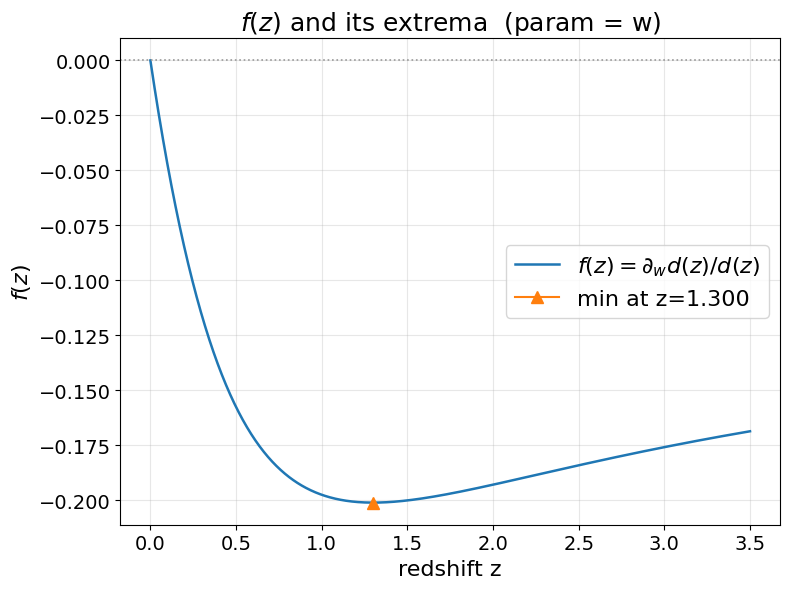

In [143]:
cosmo = dict(omega_m=0.3, omega_k=0.0, w=-1.0)

# 1) f(z) 曲线 + 极值
plot_f_with_extrema(max_z=3.5, cosmo=cosmo, param="w")

# 2) 角径距 D_A(z) 曲线 + 极值（默认 H0=70 km/s/Mpc）
# plot_DA_with_peak(max_z=5.0, cosmo=cosmo, H0=70.0)


/tmp/ipykernel_303597/572809855.py:53: IntegrationWarning: The maximum number of subdivisions (256) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  val, _ = quad(lambda x: func(x, *args), a, b, epsrel=1e-8, epsabs=0.0, limit=256)


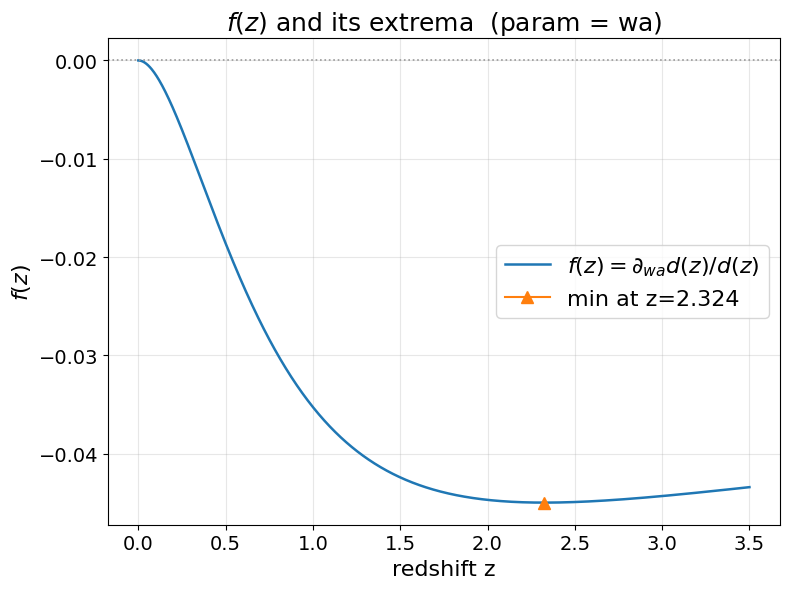

In [144]:
cosmo = dict(omega_m=0.3, omega_k=0.0, w0=-1.0, wa=0.0)

# 1) f(z) 曲线 + 极值
plot_f_with_extrema(max_z=3.5, cosmo=cosmo, param="wa")

# 2) 角径距 D_A(z) 曲线 + 极值（默认 H0=70 km/s/Mpc）
# plot_DA_with_peak(max_z=5.0, cosmo=cosmo, H0=70.0)


/tmp/ipykernel_303597/572809855.py:53: IntegrationWarning: The maximum number of subdivisions (256) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  val, _ = quad(lambda x: func(x, *args), a, b, epsrel=1e-8, epsabs=0.0, limit=256)


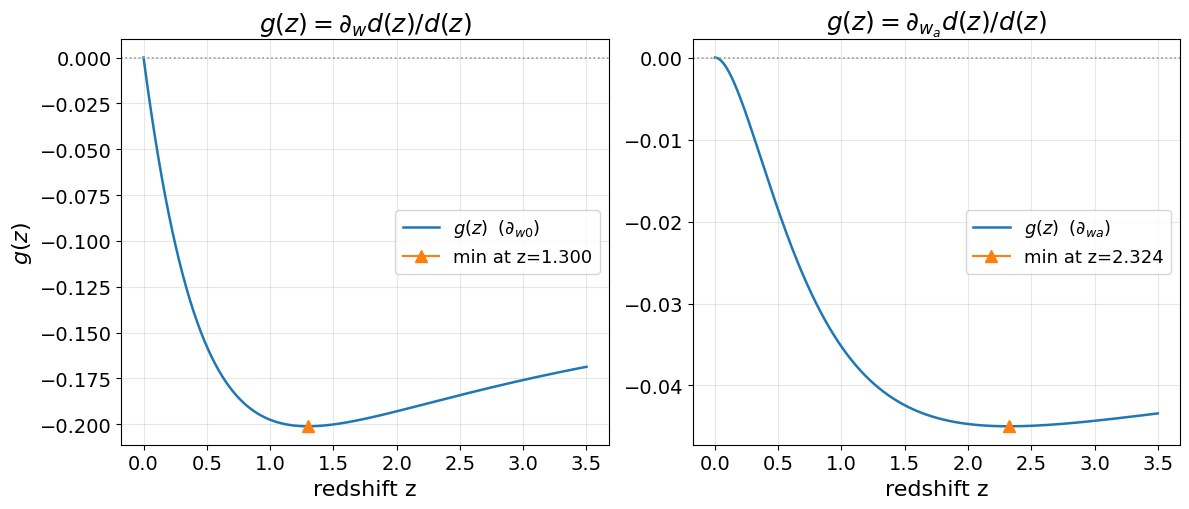

In [196]:
def _cosmo_for_param(cosmo, param):
    """
    为不同参数构造合适的宇宙学字典：
    - 对常数 w：确保有 'w'，并移除 'w0','wa'
    - 对 CPL (w0/wa)：确保没有 'w'，提供 w0/wa 缺省值
    """
    c = dict(cosmo) if cosmo is not None else {}
    if param == "w":
        # 常数 w 通道
        if "w" not in c:
            c["w"] = -1.0
        c.pop("w0", None); c.pop("wa", None)
    elif param in ("w0", "wa"):
        # CPL 通道
        c.pop("w", None)
        c.setdefault("w0", -1.0)
        c.setdefault("wa",  0.0)
    return c

def plot_f_with_extrema_two(
    max_z=3.5,
    cosmo=None,
    nz=1000,
    fs_label=16,
    fs_tick=14,
    fs_title=18,
    fs_legend=13,
    figsize=(12,5.2),
    sharey=False,   # 不共享纵轴
):
    """
    两个子图：
      左：对常数 w 的 g(z)
      右：对 CPL 的 wa 的 g(z)
    子图标题仅保留 rf"$g(z)\;\;(\partial_{{{p}}})$"
    """
    import numpy as np
    import matplotlib.pyplot as plt

    if cosmo is None:
        cosmo = dict(omega_m=0.3, omega_k=0.0, w=-1.0)

    params = ["w0", "wa"]
    titles = {
        "w0":  r"$g(z)={\partial_w d(z)}/{d(z)}$",
        "wa": r"$g(z)={\partial_{w_a} d(z)}/{d(z)}$",
    }

    zgrid = np.linspace(1e-6, max_z, nz)

    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=sharey)
    for ax, p in zip(axes, params):
        c_use = _cosmo_for_param(cosmo, p)
        fgrid = np.array([f_of_z(z, c_use, p) for z in zgrid])
        extrema = _find_extrema(zgrid, fgrid)

        ax.plot(zgrid, fgrid, lw=1.8, label=rf"$g(z)\;\;(\partial_{{{p}}})$")
        for e in extrema:
            m = "v" if e["kind"] == "max" else "^"
            ax.plot(e["z"], e["y"], marker=m, ms=8,
                    label=f"{e['kind']} at z={e['z']:.3f}")
        ax.axhline(0, ls=":", lw=1.2, color="0.6")
        ax.set_xlabel("redshift z", fontsize=fs_label)
        ax.set_title(titles[p], fontsize=fs_title)  # 子图标题
        ax.grid(alpha=0.3)
        ax.tick_params(axis='both', which='major', labelsize=fs_tick)
        ax.legend(fontsize=fs_legend, frameon=True)

    axes[0].set_ylabel(r"$g(z)$", fontsize=fs_label)
    plt.tight_layout()
    plt.savefig(r'g_function.png', bbox_inches='tight', dpi=300)
    plt.show()


# 用法示例：
# 若你原先的 cosmo 是常数 w 的：
# cosmo = dict(omega_m=0.3, omega_k=0.0, w=-1.0)
# 若你偏好 CPL 的基准，也可以：
# cosmo = dict(omega_m=0.3, omega_k=0.0, w0=-1.0, wa=0.0)

plot_f_with_extrema_two(max_z=3.5, cosmo=cosmo)
